# QDM Bias Correction of ECMWF Seasonal Forecasts: Scientific Evaluation Report

**Domain:** Horn of Africa (3.5-14.5N, 33.5-47.5E) &nbsp;|&nbsp;
**Forecast:** ECMWF SEAS5, May-init, 183-day lead &nbsp;|&nbsp;
**Reference:** CHIRPS daily precipitation, 0.25 deg &nbsp;|&nbsp;
**Hindcast period:** 1993-2025 (33 years) &nbsp;|&nbsp;
**Method:** Per-month multiplicative Quantile Delta Mapping (QDM)

This notebook walks through the full evaluation of the QDM bias correction,
comparing the **raw ECMWF ensemble** against the **QDM-corrected ensemble**,
both scored against **CHIRPS observations**, under honest
**leave-one-year-out cross-validation** (each hindcast year is corrected
using a model trained on the other 32 years only -- never itself).

Every plot below is regenerated **live, in this notebook**, by calling the
actual plotting functions from `sbc_qdm.viz` / `sbc_qdm.verify.viz` against
the cached numeric results in `output/` and `output/evaluation/` -- so the
code block above each plot is the real code that produced it, not a
throwaway re-implementation. The only exception is the domain-pooled
ECDF/PDF in Section 3.2, which would require re-scanning the full 33-year
record (~90 minutes) to recompute live; that section shows the real source
code without re-executing it, and displays the already-rendered figure.

In [1]:
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Robust to being run from the repo root or from notebooks/
_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "pyproject.toml").exists() else _here.parent
OUTPUT_DIR = PROJECT_ROOT / "output"
EVAL_DIR = OUTPUT_DIR / "evaluation"
FIGURES_DIR = OUTPUT_DIR / "figures"
EVAL_FIGURES_DIR = EVAL_DIR / "figures"


def show(path: Path):
    display(Image(filename=str(path)))


def domain_means(ds: xr.Dataset, variables: list[str]) -> pd.DataFrame:
    rows = {}
    for v in variables:
        if v in ds:
            rows[v] = float(ds[v].mean(skipna=True))
    return pd.DataFrame.from_dict(rows, orient="index", columns=["domain mean"])

## 1. Cross-Validated Daily Diagnostics

The baseline diagnostics computed directly by `sbc-qdm cross-validate`:
mean bias, wet-day frequency, CRPS/CRPSS, and the ensemble rank histogram --
all pooled over the full 33-year cross-validated hindcast at daily resolution.
Regenerated here by calling `sbc_qdm.viz` directly on the cached
`loyo_diagnostics.nc`.

In [2]:
from sbc_qdm.viz import plot_bias_maps, plot_crps, plot_crpss, plot_rank_histogram, plot_wet_day_frequency

loyo = xr.open_dataset(OUTPUT_DIR / "loyo_diagnostics.nc")
domain_means(loyo, ["raw_bias", "corrected_bias", "wet_day_freq_raw", "wet_day_freq_corrected", "crps_raw", "crps_corrected", "crpss"])

,domain mean
raw_bias,0.3815
corrected_bias,-0.0372
wet_day_freq_raw,0.2527
wet_day_freq_corrected,0.1633
crps_raw,2.0400
crps_corrected,1.8434
crpss,0.1064


### 1.1 Mean bias

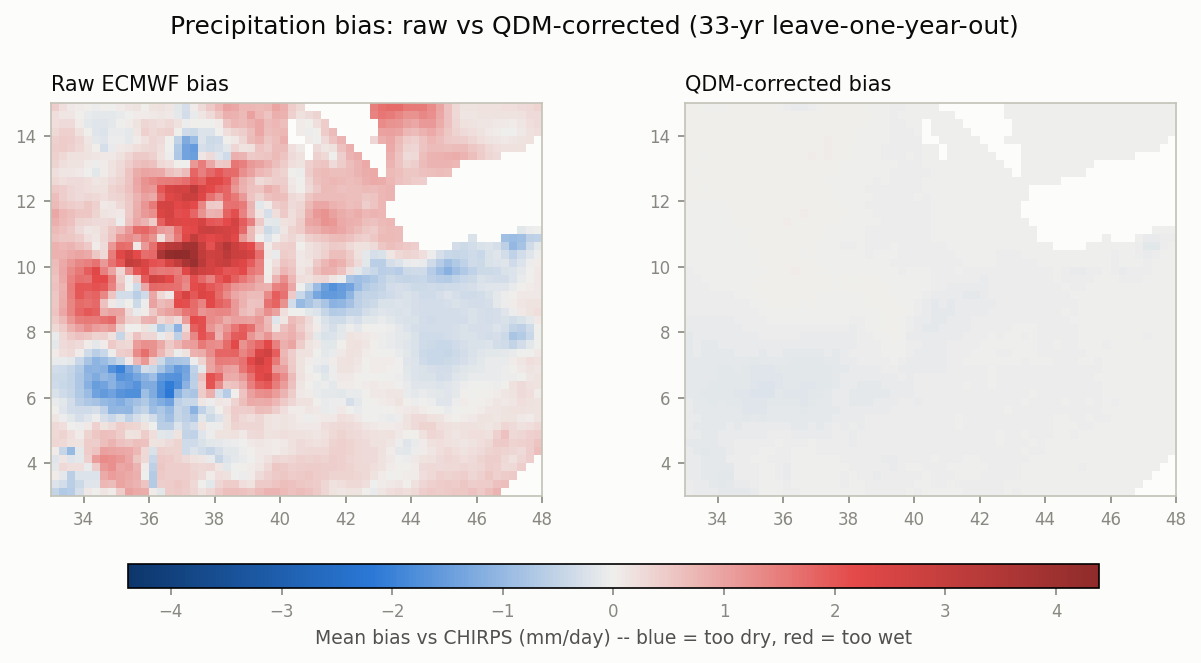

In [3]:
plot_bias_maps(loyo, FIGURES_DIR / "bias_maps.png")
show(FIGURES_DIR / "bias_maps.png")

**Reading it:** the raw forecast has a strong, spatially coherent wet bias
over the western highlands of the domain (dark red patch) with some drier
patches nearby. After correction, the map is almost uniformly near-white --
the systematic spatial bias pattern is essentially eliminated. Domain-mean
bias goes from **+0.38 mm/day** (raw) to **-0.04 mm/day** (corrected), a
~92% reduction.

### 1.2 Wet-day frequency

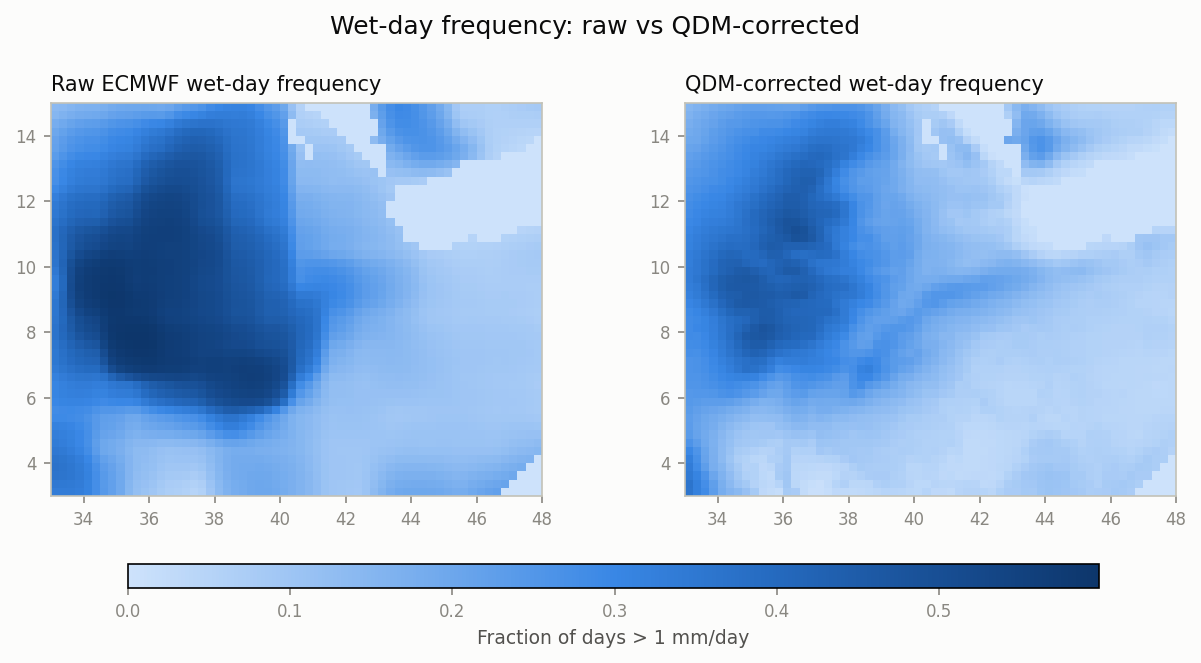

In [4]:
plot_wet_day_frequency(loyo, FIGURES_DIR / "wet_day_frequency.png")
show(FIGURES_DIR / "wet_day_frequency.png")

**Reading it:** raw ECMWF rains on **25.3%** of ensemble-member-days
domain-wide; after correction this drops to **16.3%**. This is
`xsdba.processing.adapt_freq` doing its job -- ECMWF's well-known tendency to
"drizzle" (rain too often, too lightly) is being corrected toward CHIRPS'
observed dry-day frequency.

### 1.3 CRPS and CRPS Skill Score (CRPSS)

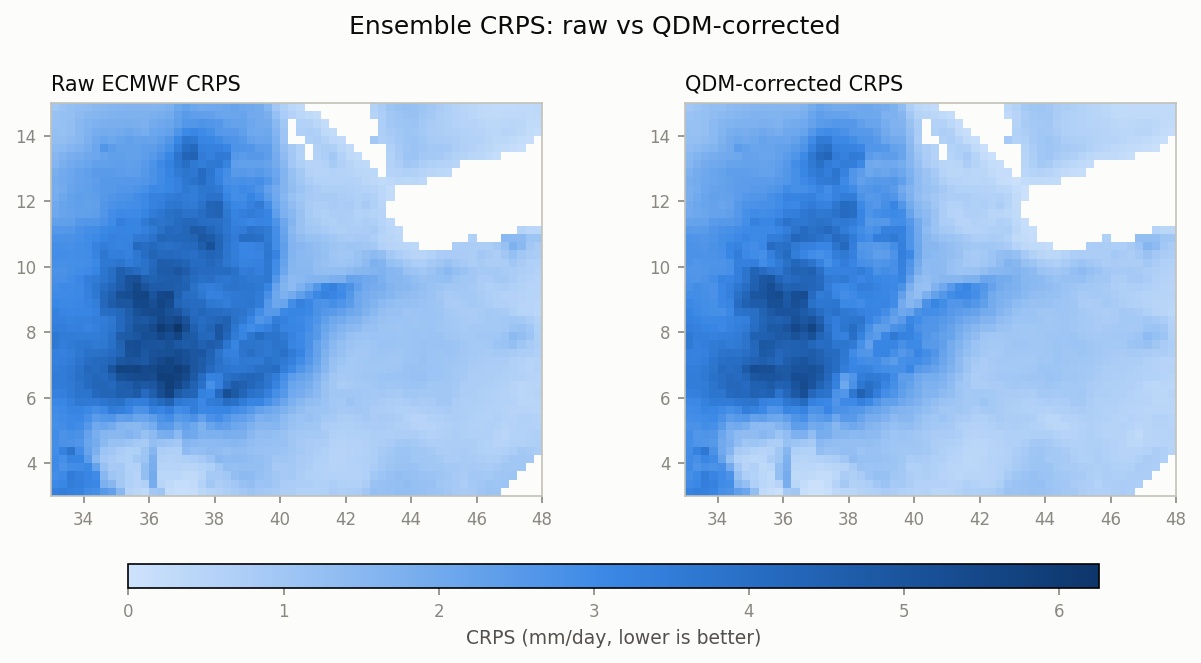

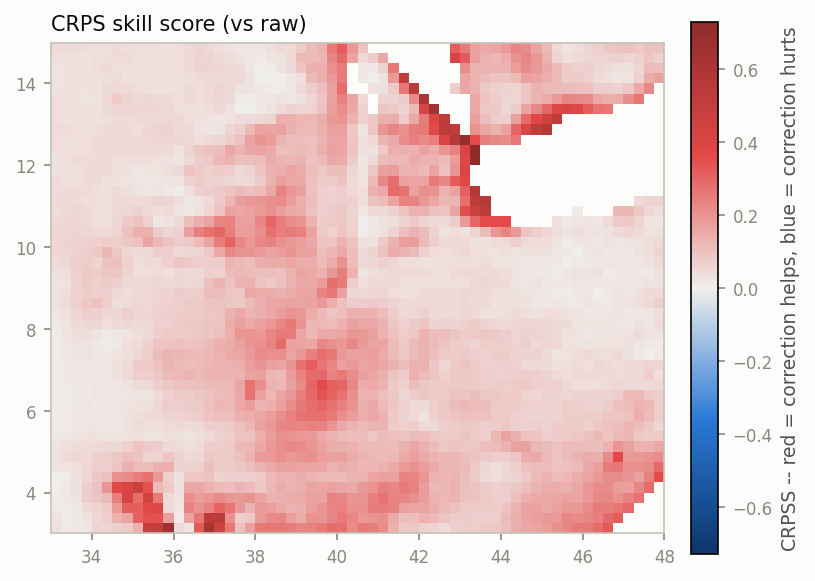

In [5]:
plot_crps(loyo, FIGURES_DIR / "crps.png")
plot_crpss(loyo, FIGURES_DIR / "crpss.png")
show(FIGURES_DIR / "crps.png")
show(FIGURES_DIR / "crpss.png")

**Reading it:** CRPS (lower is better) improves modestly domain-wide
(2.040 -> 1.843, ~10% better), and the CRPSS map is positive (red) across
nearly the entire domain -- the correction is a net improvement to ensemble
forecast quality almost everywhere, not just on average.

### 1.4 Rank histogram (ensemble calibration)

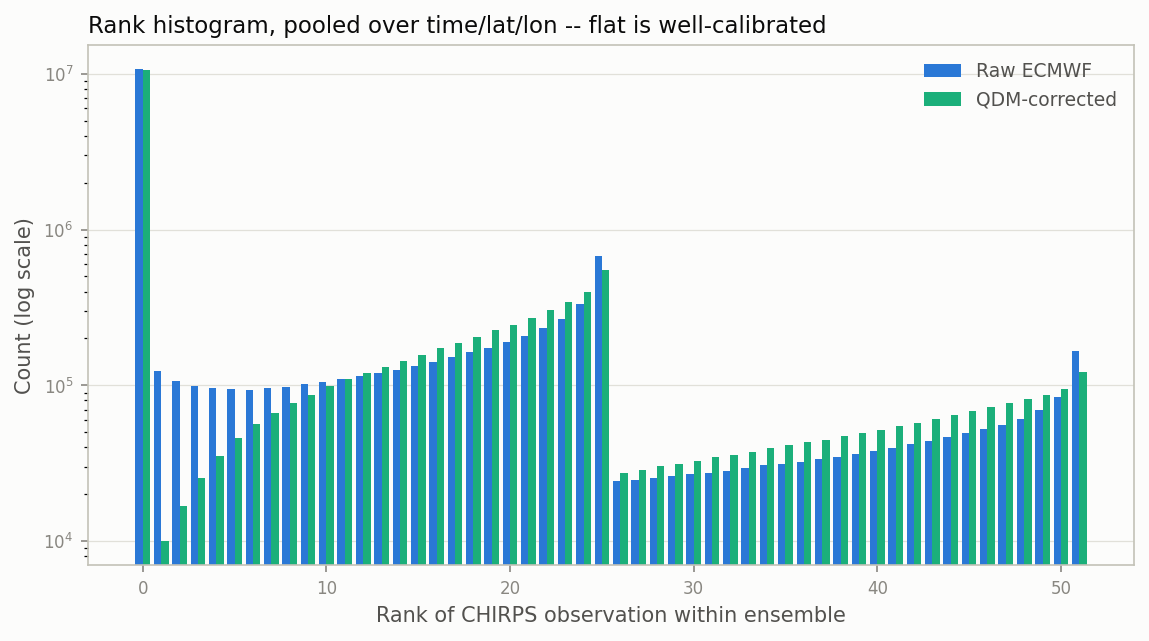

In [6]:
plot_rank_histogram(loyo, FIGURES_DIR / "rank_histogram.png")
show(FIGURES_DIR / "rank_histogram.png")

**Reading it:** log-scale y-axis, because the rank-0 bin (dry days where
CHIRPS is at or below every ensemble member) is ~40x taller than the rest --
an expected feature of zero-inflated precipitation, not miscalibration.
Note the visible break at rank 25/26: hindcast years before 2017 only have
25 ensemble members, so they can never register above rank 25 in this pooled
histogram -- a real structural artifact of the ensemble-size change, not a bug.

## 2. Daily Deterministic Metrics (Full Evaluation Suite)

Beyond the cross-validation basics: Mean Bias Error, Mean Absolute Error,
Percentage Bias, RMSE, and the standard-deviation / coefficient-of-variation
ratios, plus quantile-specific bias and ensemble spread-skill ratio.
Regenerated from the cached `daily_deterministic.nc`.

In [7]:
daily = xr.open_dataset(EVAL_DIR / "daily_deterministic.nc")
rows = []
for metric in ["mbe", "mae", "pbias", "rmse", "sd_ratio", "cv_ratio", "wet_day_freq_bias", "spread_skill_ratio"]:
    raw_name, corr_name = f"raw_{metric}", f"corrected_{metric}"
    if raw_name in daily and corr_name in daily:
        rows.append({"metric": metric, "raw": float(daily[raw_name].mean()), "corrected": float(daily[corr_name].mean())})
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
mbe,0.3815,-0.0372
mae,3.0751,2.8489
pbias,31.7536,-2.4900
rmse,5.0289,4.9507
sd_ratio,0.4235,0.4151
cv_ratio,0.3281,0.4255


### 2.1 Mean Bias Error and RMSE

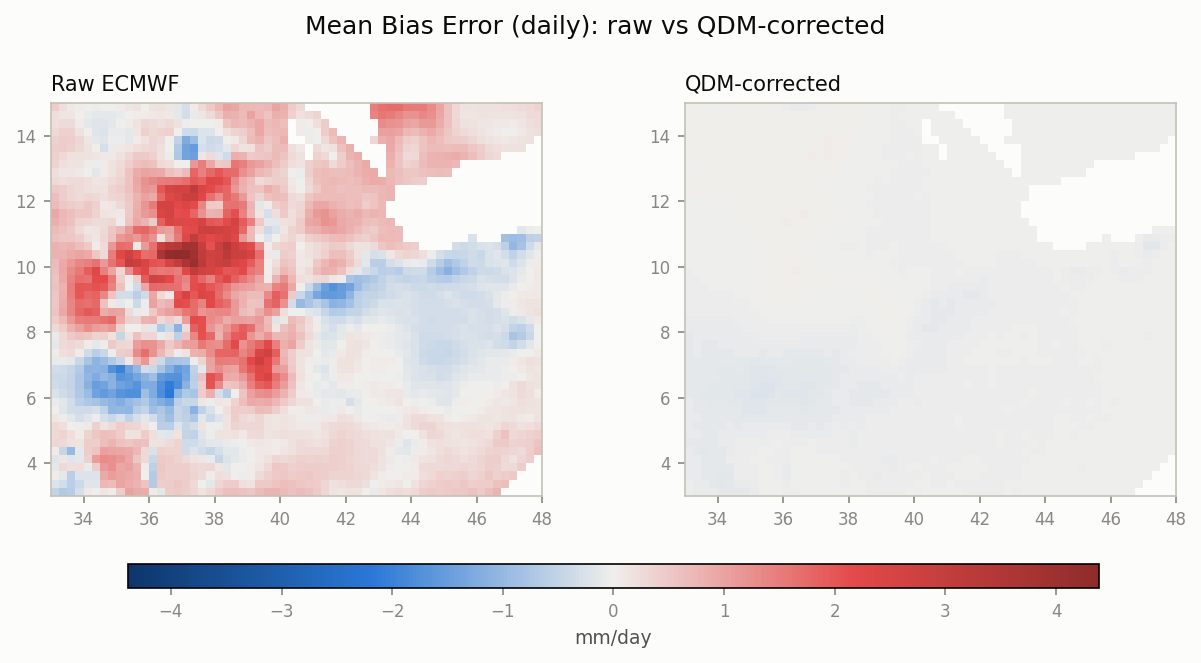

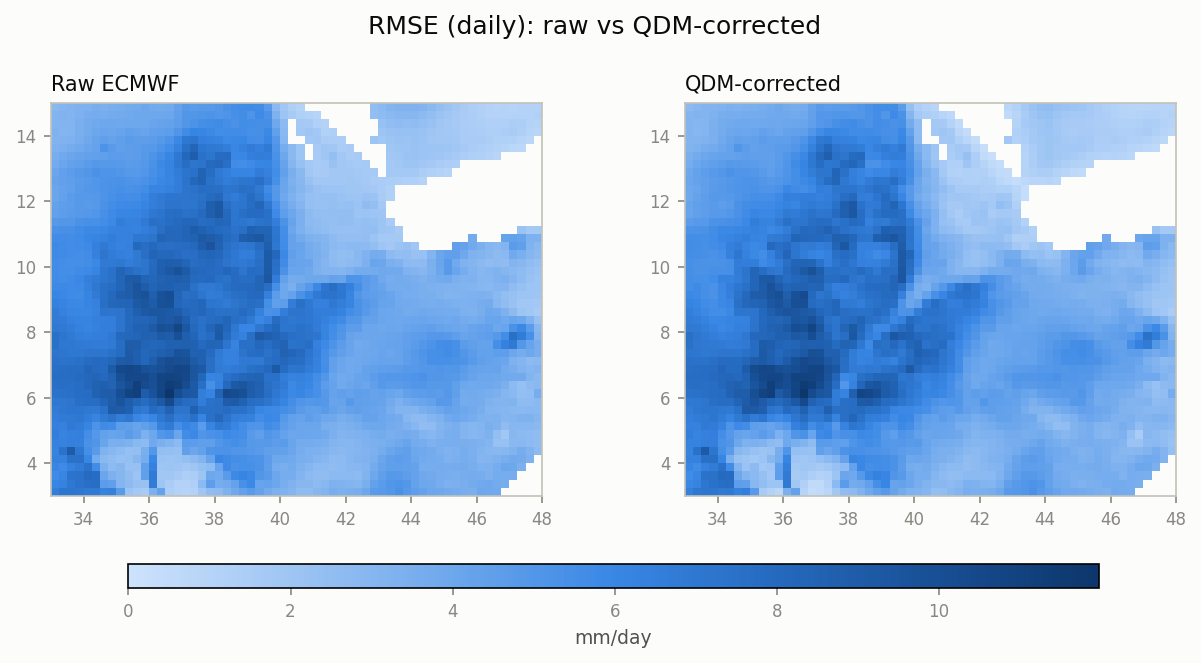

In [8]:
from sbc_qdm.verify.viz import plot_deterministic_map

plot_deterministic_map(daily["raw_mbe"], daily["corrected_mbe"], EVAL_FIGURES_DIR / "daily_mbe.png", "Mean Bias Error (daily)", "mm/day")
plot_deterministic_map(daily["raw_rmse"], daily["corrected_rmse"], EVAL_FIGURES_DIR / "daily_rmse.png", "RMSE (daily)", "mm/day", diverging=False)
show(EVAL_FIGURES_DIR / "daily_mbe.png")
show(EVAL_FIGURES_DIR / "daily_rmse.png")

**Reading it:** MBE improves the same way the cross-validation bias map did.
RMSE, however, barely moves (5.03 -> 4.96 mm/day, ~1.4%) -- because daily RMSE
is dominated by unpredictable day-to-day timing error, which a purely
*marginal* correction like QDM (it remaps each day's value independently,
using no information about neighboring days) has no mechanism to fix.

### 2.2 Percentage Bias (PBIAS)

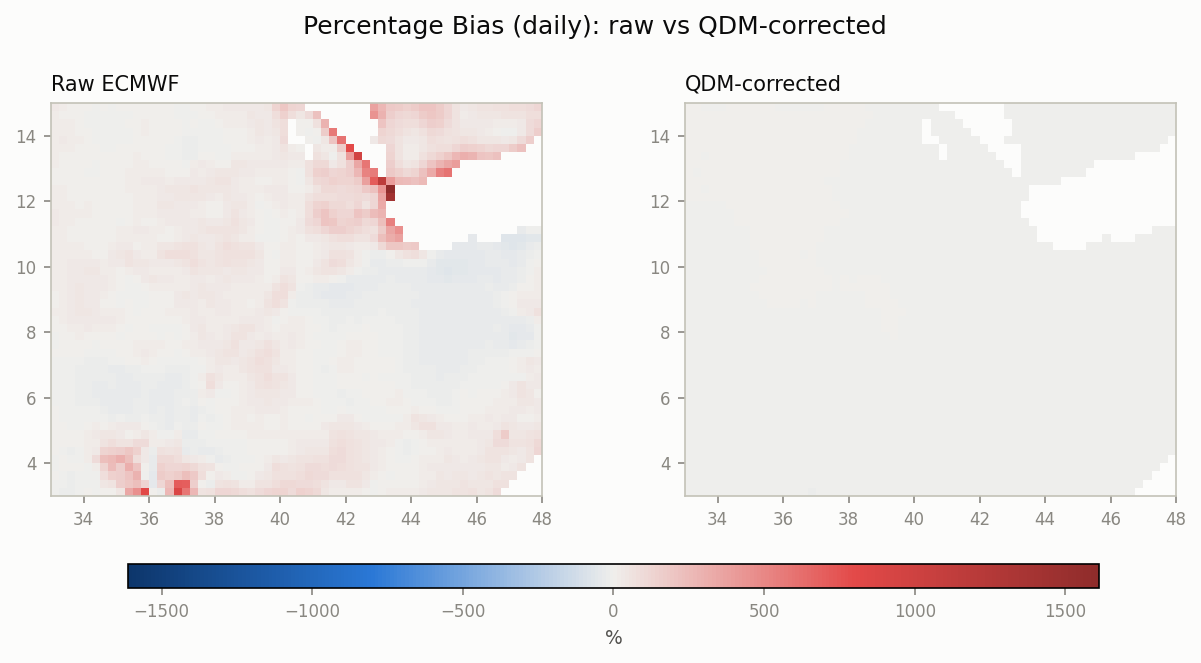

In [9]:
plot_deterministic_map(daily["raw_pbias"], daily["corrected_pbias"], EVAL_FIGURES_DIR / "daily_pbias.png", "Percentage Bias (daily)", "%")
show(EVAL_FIGURES_DIR / "daily_pbias.png")

**Reading it:** PBIAS goes from **+31.8%** (raw over-forecasts total volume
by nearly a third) to **-2.5%** -- the clearest single number showing how
thoroughly QDM fixes the systematic volume bias.

### 2.3 Quantile bias (Q10 / Q50 / Q90 / Q95)

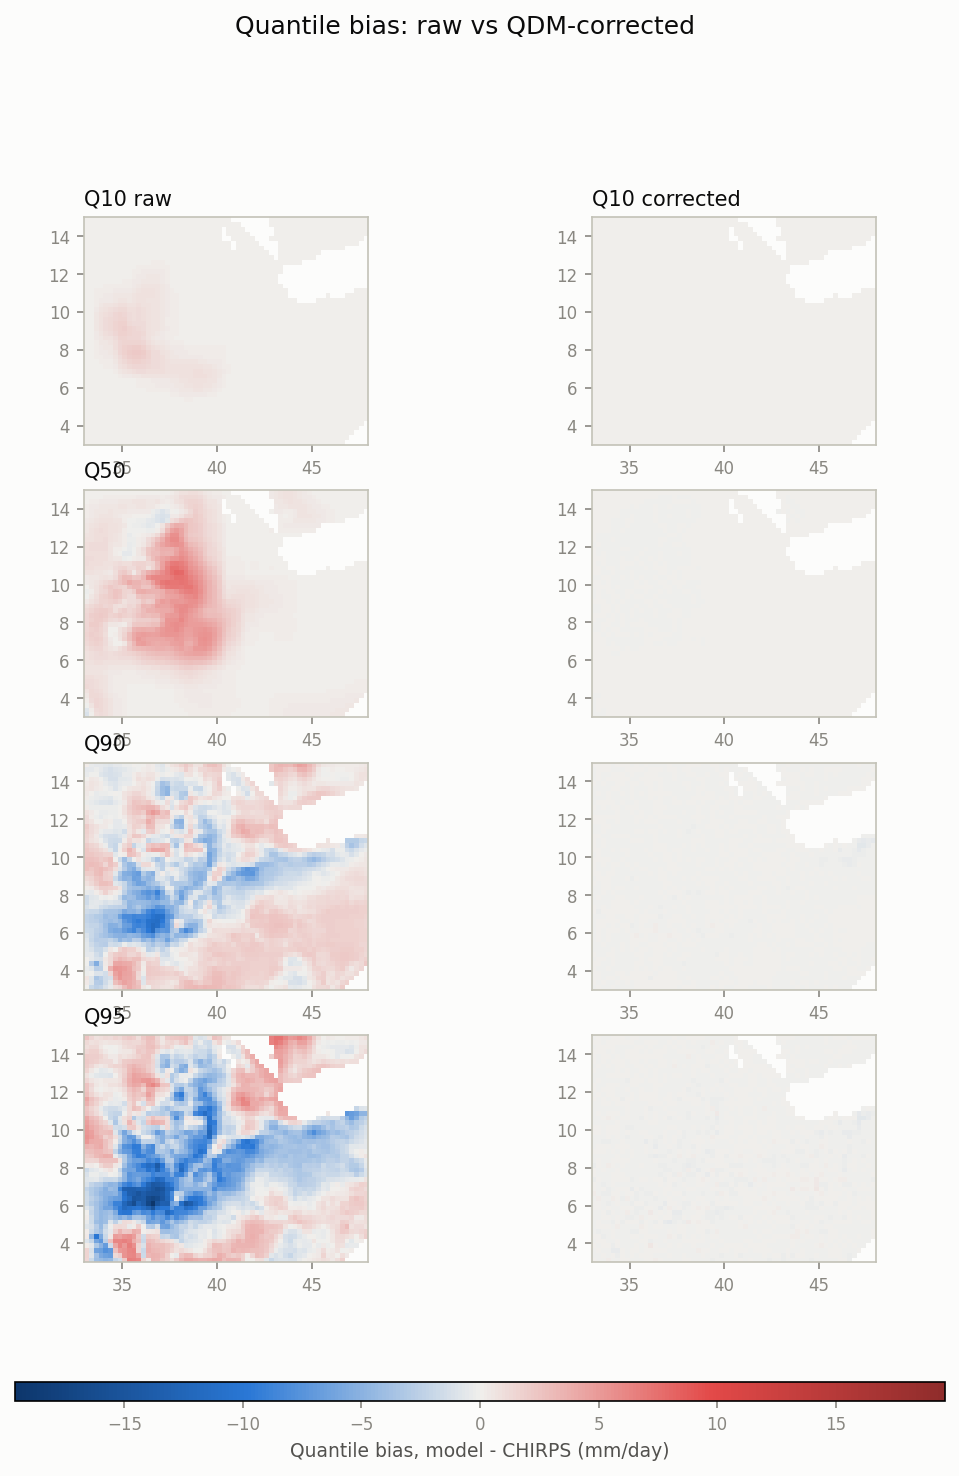

In [10]:
from sbc_qdm.verify.viz import plot_quantile_bias_grid

plot_quantile_bias_grid(daily["quantile_bias_raw"], daily["quantile_bias_corrected"], EVAL_FIGURES_DIR / "quantile_bias.png")
show(EVAL_FIGURES_DIR / "quantile_bias.png")

**Reading it:** bias at the low-to-middle quantiles (Q10, Q50) is corrected
well. At the upper quantiles (Q90, Q95) the correction is doing more work --
watch for this alongside the Q-Q plot in Section 3, which shows the same
upper-tail behavior more starkly.

### 2.4 Ensemble spread-skill ratio

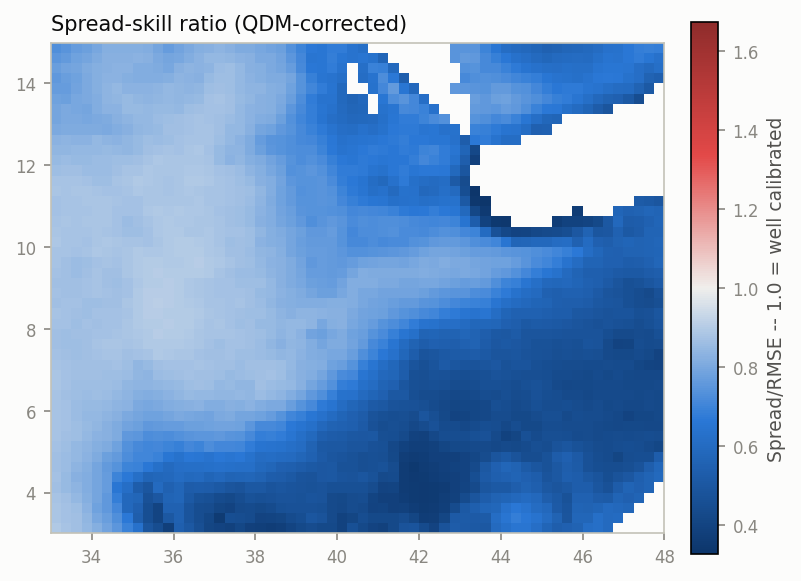

In [11]:
from sbc_qdm.verify.viz import plot_spread_skill_map

plot_spread_skill_map(daily["spread_skill_ratio_corrected"], EVAL_FIGURES_DIR / "spread_skill_ratio.png")
show(EVAL_FIGURES_DIR / "spread_skill_ratio.png")

**Reading it:** ratio of ensemble spread (std across members) to the RMSE of
the ensemble mean -- 1.0 (white) means a well-calibrated ensemble, where the
spread accurately reflects the forecast's actual uncertainty.

## 3. Distributional Similarity

Domain-pooled comparisons of the full daily precipitation distribution --
CHIRPS vs raw ECMWF vs QDM-corrected -- rather than a per-pixel summary.

### 3.1 Quantile-Quantile (Q-Q) plot

Cheap to regenerate: the sorted quantile pairs were cached in `qq_pairs.nc`
during the original (expensive) run, so replotting here doesn't need to
rescan the raw 33-year record.

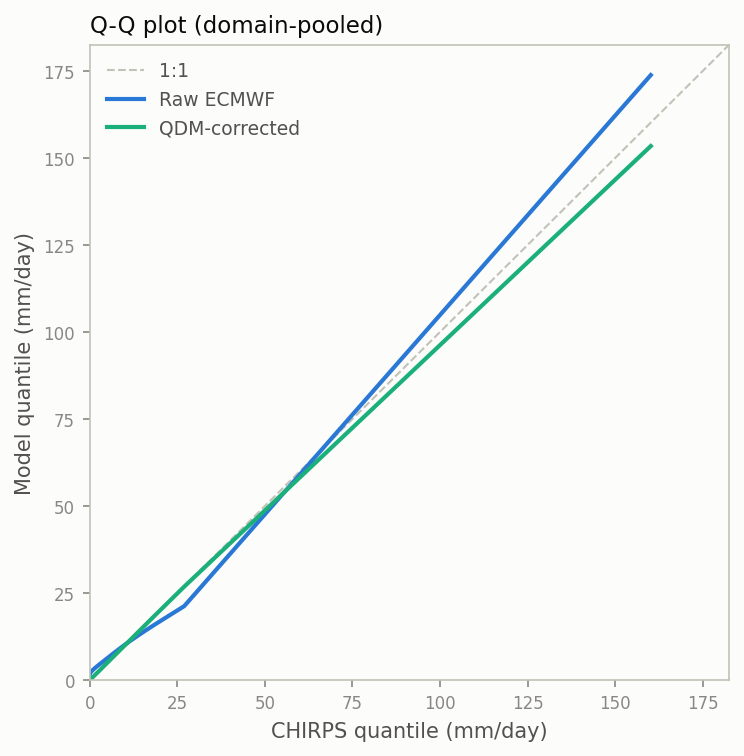

In [12]:
from sbc_qdm.verify.viz import plot_qq

qq = xr.open_dataset(EVAL_DIR / "qq_pairs.nc")
plot_qq(qq["ref"].values, qq["raw"].values, qq["corrected"].values, EVAL_FIGURES_DIR / "qq_plot.png")
show(EVAL_FIGURES_DIR / "qq_plot.png")

**Reading it -- the most important caveat in this whole report:** through
the bulk of the distribution, the corrected quantiles (green) track the 1:1
CHIRPS line closely, much better than raw (blue). But above roughly the 95th
percentile, the corrected line diverges *above* both the 1:1 line and the raw
forecast -- QDM is amplifying extreme values beyond what either the raw model
or CHIRPS itself has ever produced. This is connected to the domain's single
most extreme value in the operational 2026 corrected forecast --
**traced to an exact mechanism, not just a pattern in aggregate, with live
numbers computed from the actual output**, in Section 8 below.

### 3.2 Empirical CDF and probability density

**Not re-executed here.** `dist.ecdf()`/`dist.pdf_histogram()` stream the
*entire* 33-year x 51-member x full-domain array in (lat,lon) blocks to build
a domain-pooled sample (see `verify/aggregate.py`'s `iter_spatial_blocks`) --
in the original run this took roughly 90 minutes across the 6 obs/raw/
corrected ECDF+PDF calls, and unlike the Q-Q pairs above, the underlying
curve data wasn't cached separately. The cell below shows the actual source
that produced the cached figure instead of re-running it.

In [13]:
from sbc_qdm.verify import distributions as dist
from sbc_qdm.verify.viz import plot_ecdf, plot_pdf

print(inspect.getsource(dist.ecdf))
print(inspect.getsource(dist.pdf_histogram))
print(inspect.getsource(plot_ecdf))
print(inspect.getsource(plot_pdf))

def ecdf(da: xr.DataArray, n_points: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Domain-pooled empirical CDF: (sorted_x, F(x)), subsampled to n_points."""
    sorted_vals = np.sort(_flatten_valid(da))
    n = len(sorted_vals)
    y = np.arange(1, n + 1) / n
    if n > n_points:
        idx = np.linspace(0, n - 1, n_points).astype(int)
        return sorted_vals[idx], y[idx]
    return sorted_vals, y

def pdf_histogram(da: xr.DataArray, bins: int = 60, value_range: tuple[float, float] | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Domain-pooled density histogram: (bin_centers, density).

    A plain histogram rather than a KDE -- precipitation's point-mass at zero
    (dry days) would be smeared out by kernel smoothing into a misleadingly
    continuous-looking density near zero.
    """
    flat = _flatten_valid(da)
    counts, edges = np.histogram(flat, bins=bins, range=value_range, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, counts

d

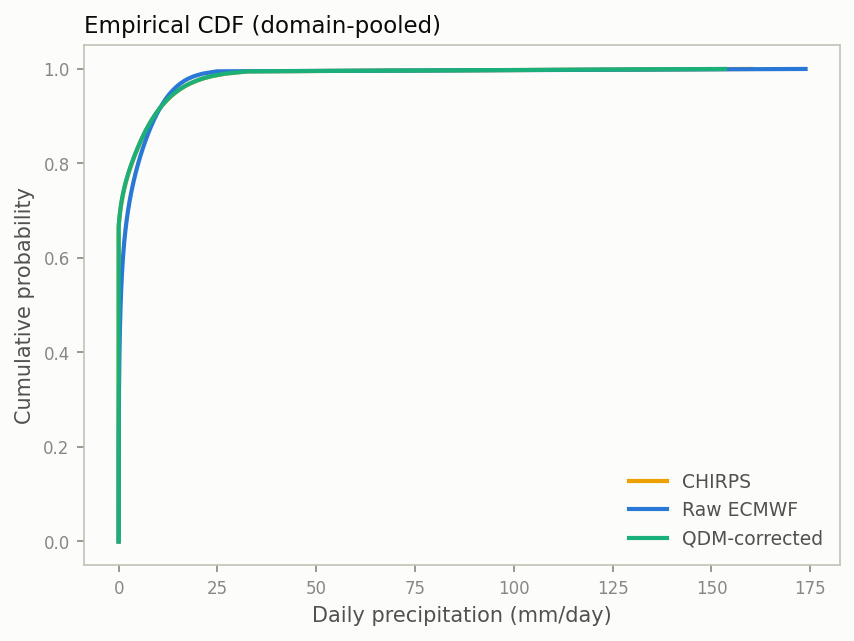

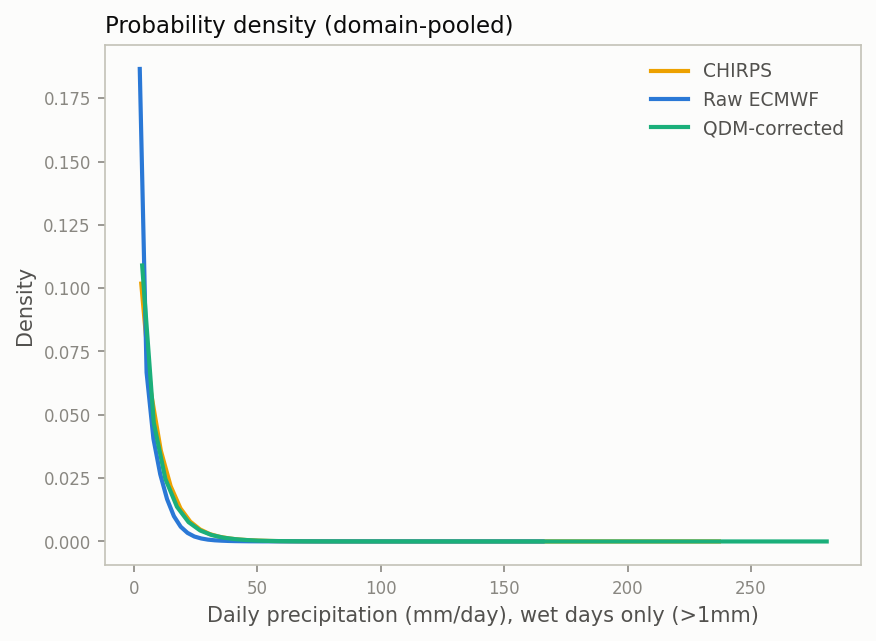

In [14]:
show(EVAL_FIGURES_DIR / "ecdf.png")
show(EVAL_FIGURES_DIR / "pdf.png")

**Reading it:** the ECDF confirms the corrected distribution (green) sits
much closer to CHIRPS (yellow) than raw (blue) does through most of its
range. The PDF (wet days only, >1mm) shows the corrected distribution's
shape converging toward CHIRPS' in the low-to-moderate rainfall range.

## 4. Wet/Dry Spell Persistence

Does the correction fix how long wet and dry spells tend to last -- not just
how much rain falls on any given day? Regenerated from the cached raw
spell-length samples (`spell_lengths.npz`) -- the expensive part (extracting
run-lengths from every pixel/member time series) already happened during
`sbc-qdm evaluate`; rebuilding the histogram from those cached arrays is a
cheap numpy operation.

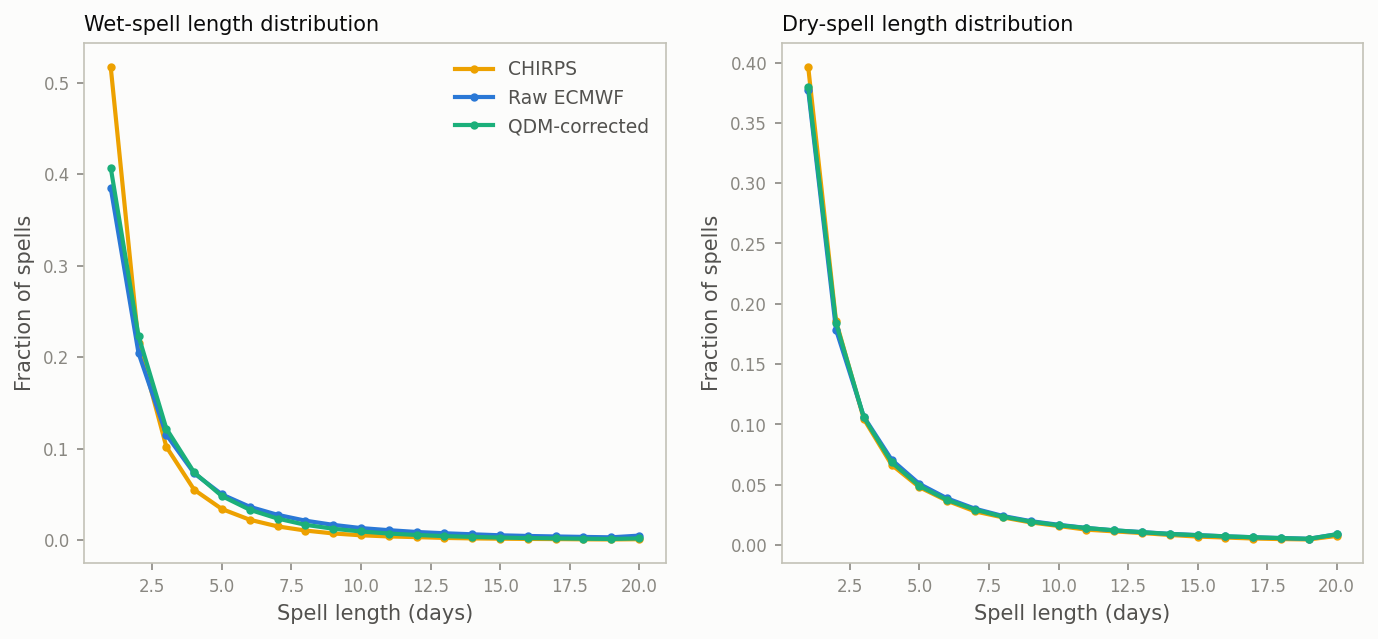

In [15]:
from sbc_qdm.verify.viz import plot_spell_distributions

spell_lengths = np.load(EVAL_DIR / "spell_lengths.npz")
plot_spell_distributions(
    spell_lengths["obs_wet"], spell_lengths["raw_wet"], spell_lengths["corrected_wet"],
    spell_lengths["obs_dry"], spell_lengths["raw_dry"], spell_lengths["corrected_dry"],
    EVAL_FIGURES_DIR / "spell_distributions.png",
)
show(EVAL_FIGURES_DIR / "spell_distributions.png")

**Reading it:** dry-spell length distributions are essentially identical
across CHIRPS, raw, and corrected -- unsurprising, since QDM barely touches
dry-day classification. More notably, **wet-spell lengths are also barely
changed by the correction**: CHIRPS shows a much sharper spike at 1-day wet
spells (52%) than either raw (39%) or corrected (41%) reproduce, meaning
both the raw and corrected forecasts still overstate the persistence of
rain events relative to reality. This is expected -- QDM corrects each day's
magnitude independently and has no mechanism to fix day-to-day sequencing --
but it's a genuine limitation worth stating plainly rather than implying the
correction fixes everything.

## 5. Spatial Performance

The complement to the per-pixel maps above: for each day, how well does the
model's *spatial pattern* match CHIRPS' spatial pattern (after removing each
pixel's own long-term climatology, so a shared wet/dry climatological
gradient doesn't inflate the score)? Regenerated from the cached
`daily_spatial_timeseries.nc` (one value per day -- small, cheap to replot).

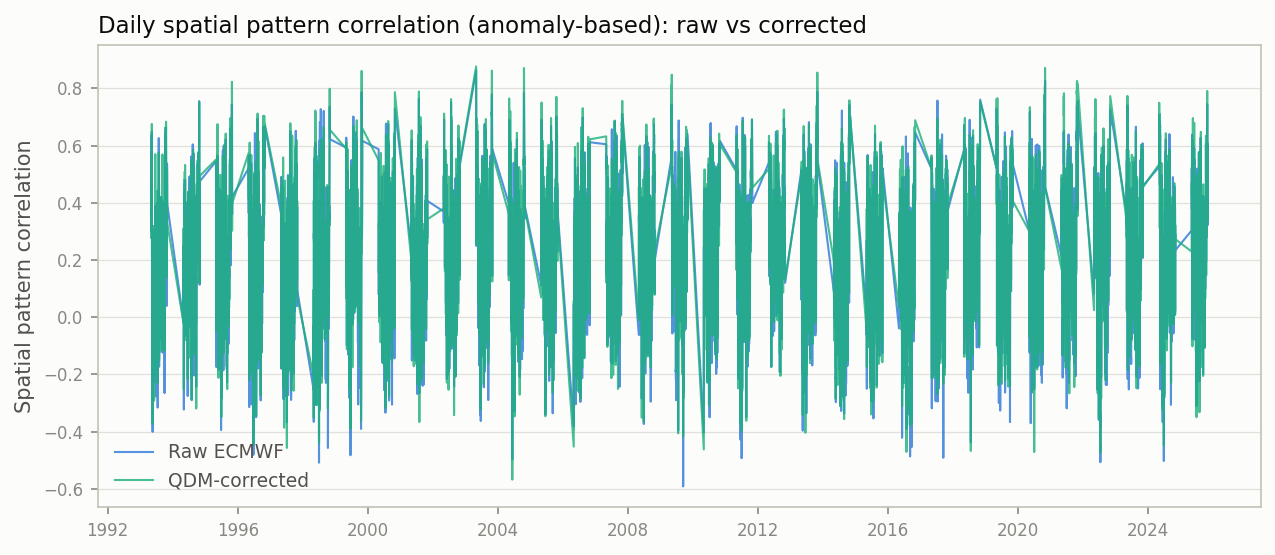

In [16]:
from sbc_qdm.verify.viz import plot_spatial_metric_timeseries

spatial_ts = xr.open_dataset(EVAL_DIR / "daily_spatial_timeseries.nc")
plot_spatial_metric_timeseries(
    spatial_ts["spatial_pattern_correlation_raw"], spatial_ts["spatial_pattern_correlation_corrected"],
    EVAL_FIGURES_DIR / "spatial_pattern_correlation.png",
    "Spatial pattern correlation", "Daily spatial pattern correlation (anomaly-based): raw vs corrected",
)
show(EVAL_FIGURES_DIR / "spatial_pattern_correlation.png")

**Reading it:** a noisy but broadly comparable time series for raw vs
corrected -- QDM operates pixel-by-pixel with no explicit spatial-consistency
term, so it isn't expected to systematically improve (or degrade) how well
the model captures the *spatial shape* of a given day's anomaly.

## 6. Deterministic Skill vs Climatology (JJAS Season Total)

Aggregating to the JJAS (June-September) seasonal total -- the core Horn of
Africa rains -- and asking: does the model beat a naive "predict the
long-term normal every year" climatology forecast? Regenerated from the
cached `jjas_deterministic_and_skill.nc`.

In [17]:
jjas = xr.open_dataset(EVAL_DIR / "jjas_deterministic_and_skill.nc")
rows = []
for metric in ["mbe", "rmse", "acc", "spearman_acc", "rmsess", "interannual_variability_ratio"]:
    raw_name, corr_name = f"raw_{metric}", f"corrected_{metric}"
    if raw_name in jjas and corr_name in jjas:
        rows.append({"metric": metric, "raw": float(jjas[raw_name].mean()), "corrected": float(jjas[corr_name].mean())})
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
mbe,56.8142,-4.7746
rmse,110.1733,56.6532
acc,0.2419,0.2018
spearman_acc,0.2323,0.1950
rmsess,-2.5838,-0.1796
interannual_variability_ratio,1.1052,0.8193


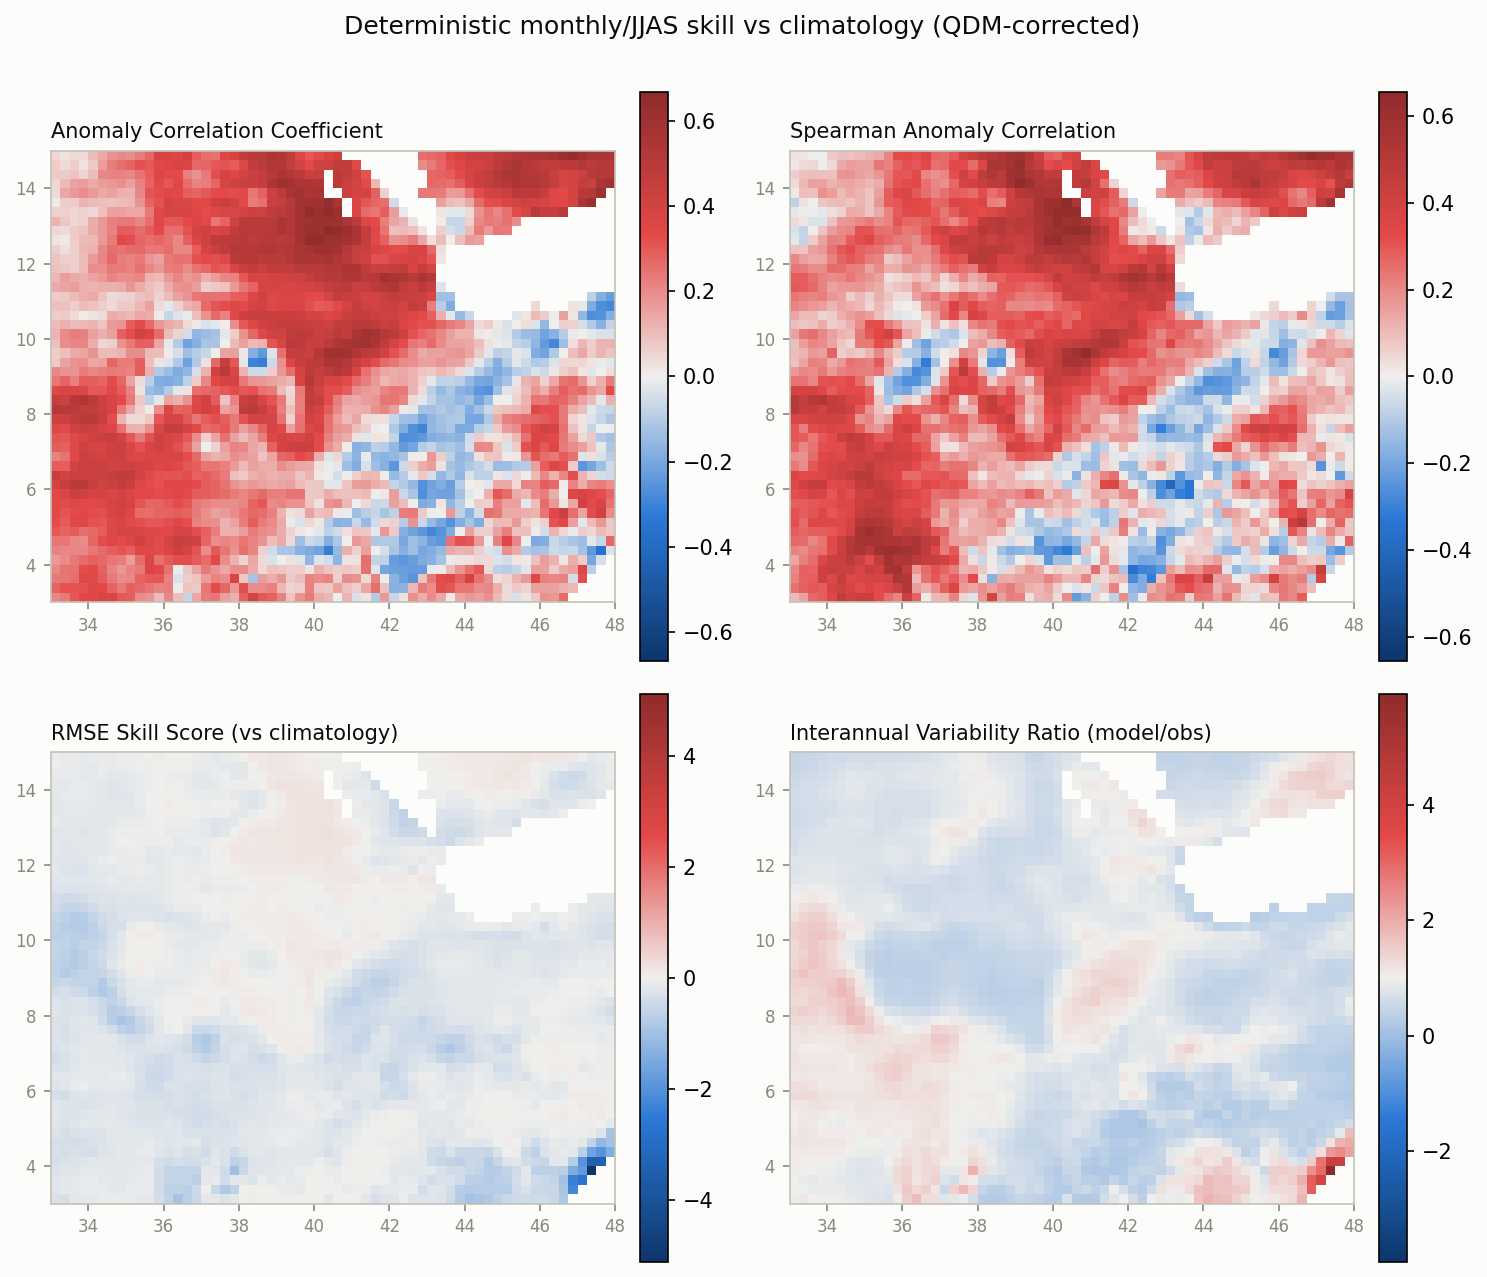

In [18]:
from sbc_qdm.verify.viz import plot_skill_maps

plot_skill_maps(
    jjas["corrected_acc"], jjas["corrected_spearman_acc"], jjas["corrected_rmsess"], jjas["corrected_interannual_variability_ratio"],
    EVAL_FIGURES_DIR / "jjas_skill_maps.png",
)
show(EVAL_FIGURES_DIR / "jjas_skill_maps.png")

**Reading it:** JJAS-total RMSE improves dramatically (110.2mm -> 56.7mm,
~49%) -- at this aggregated scale, random day-to-day noise cancels out
through summation and the systematic bias fix dominates, unlike daily RMSE
in Section 2 which barely moved. RMSE Skill Score (vs climatology) goes from
deeply negative (-2.58, much worse than climatology) to only slightly
negative (-0.18, nearly on par) -- a large improvement, though not yet fully
"skillful" against naive climatology.

The Anomaly Correlation Coefficient (ACC), however, tells a different story:
it **drops slightly** after correction (0.242 -> 0.202), as does the
interannual variability ratio moving further from 1.0 (1.105 -> 0.819). QDM
targets the marginal distribution, not year-to-year rank correlation or
interannual spread directly, so it's not guaranteed -- and here didn't
happen -- to improve every skill dimension simultaneously.

## 7. Probabilistic Ensemble Skill (Tercile-Category Forecasts)

Scoring the ensemble as a probabilistic forecast of below-normal /
near-normal / above-normal JJAS-total categories, defined from CHIRPS' own
climatological terciles -- the standard WMO/IRI convention for seasonal
forecast verification. Regenerated from the cached `jjas_probabilistic.nc`.

In [19]:
prob = xr.open_dataset(EVAL_DIR / "jjas_probabilistic.nc")
rows = [
    {"metric": "RPSS", "raw": float(prob["raw_rpss"].mean()), "corrected": float(prob["corrected_rpss"].mean())},
    {"metric": "BSS (above-normal)", "raw": float(prob["raw_bss"].sel(category="above").mean()), "corrected": float(prob["corrected_bss"].sel(category="above").mean())},
    {"metric": "ROC skill (above-normal)", "raw": float(prob["raw_roc_skill_score"].sel(category="above").mean()), "corrected": float(prob["corrected_roc_skill_score"].sel(category="above").mean())},
    {"metric": "CRPS", "raw": float(prob["crps_raw"].mean()), "corrected": float(prob["crps_corrected"].mean())},
]
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
RPSS,-0.2636,-0.0527
BSS (above-normal),-0.2180,-0.0261
ROC skill (above-normal),0.2456,0.2433
CRPS,72.8147,32.5708


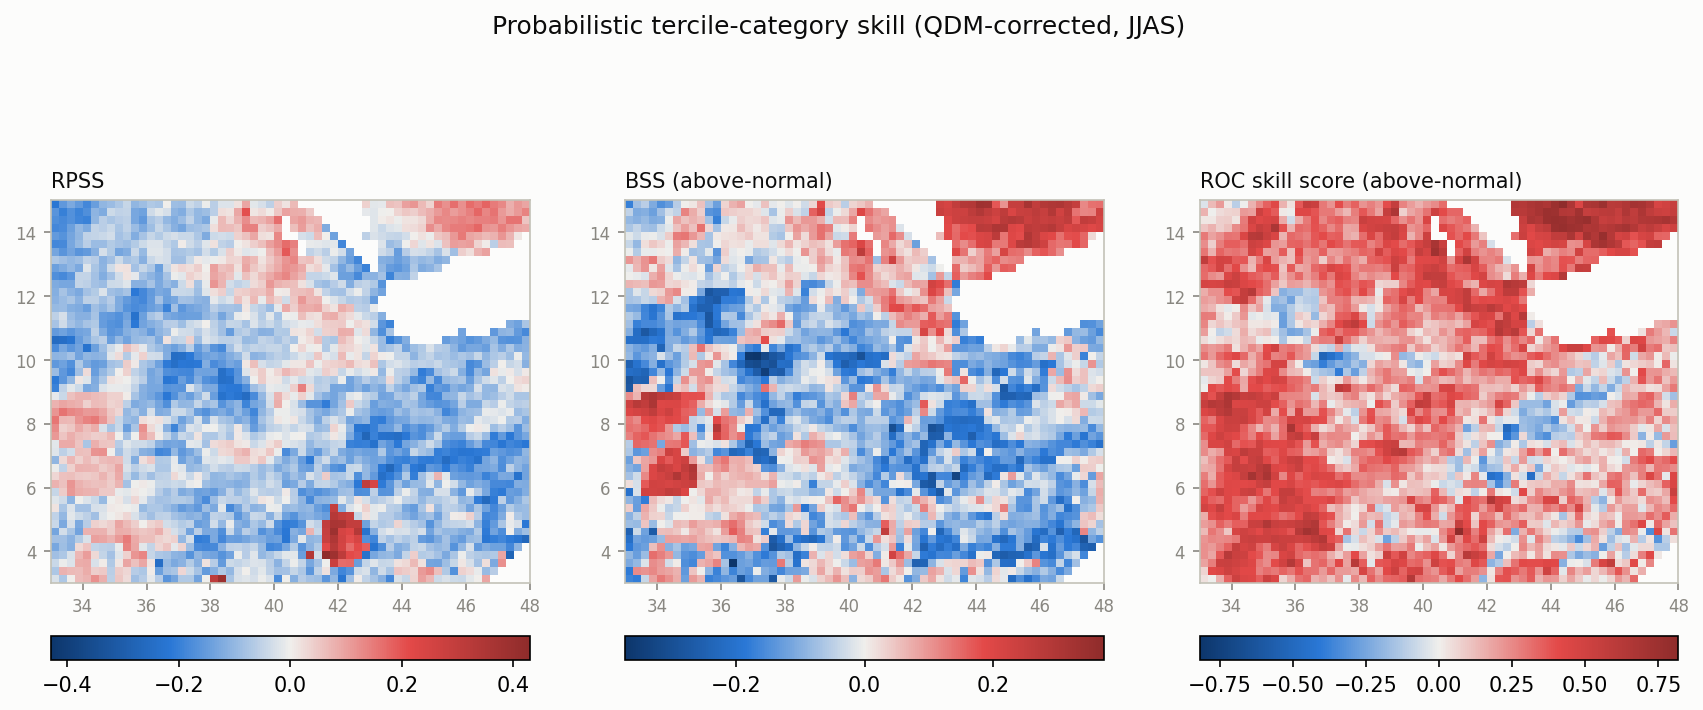

In [20]:
from sbc_qdm.verify.viz import plot_probabilistic_skill_maps

plot_probabilistic_skill_maps(
    prob["corrected_rpss"], prob["corrected_bss"].sel(category="above"), prob["corrected_roc_skill_score"].sel(category="above"),
    EVAL_FIGURES_DIR / "jjas_probabilistic_skill.png",
)
show(EVAL_FIGURES_DIR / "jjas_probabilistic_skill.png")

**Reading it -- the clearest methodological insight in this report:** RPSS
and BSS both improve substantially after correction (RPSS: -0.264 -> -0.053;
BSS: -0.218 -> -0.026), while ROC skill score is essentially **unchanged**
(0.246 -> 0.243). This is textbook-consistent: RPSS/BSS are sensitive to
probability *calibration* (is the forecast probability the right magnitude?),
which QDM directly improves by fixing the marginal distribution. ROC skill
measures *discrimination* (can the ensemble rank which years will be
above-normal, regardless of the probability's absolute scale?) -- a
monotonic quantile transform preserves rank order within each training fold,
so discrimination ability is mostly untouched by this kind of correction.

Spatially, RPSS/BSS are positive (red) in the northeast of the domain but
negative (blue) through the central-south, while ROC skill is strongly
positive almost everywhere -- the ensemble discriminates above-normal
seasons reasonably well nearly everywhere, but its absolute probability
calibration is still poor in the central/southern part of the domain even
where discrimination is fine.

### 7.1 Reliability diagram (above-normal event)

The RPSS/BSS/ROC arrays above were cached, but not the underlying per-year
tercile probabilities the reliability diagram needs -- this cell recomputes
just those (JJAS-aggregating the cached `loyo_corrected.nc` and re-deriving
CHIRPS' tercile thresholds), a couple of minutes of work, not the ~90-minute
cost of the ECDF/PDF section.

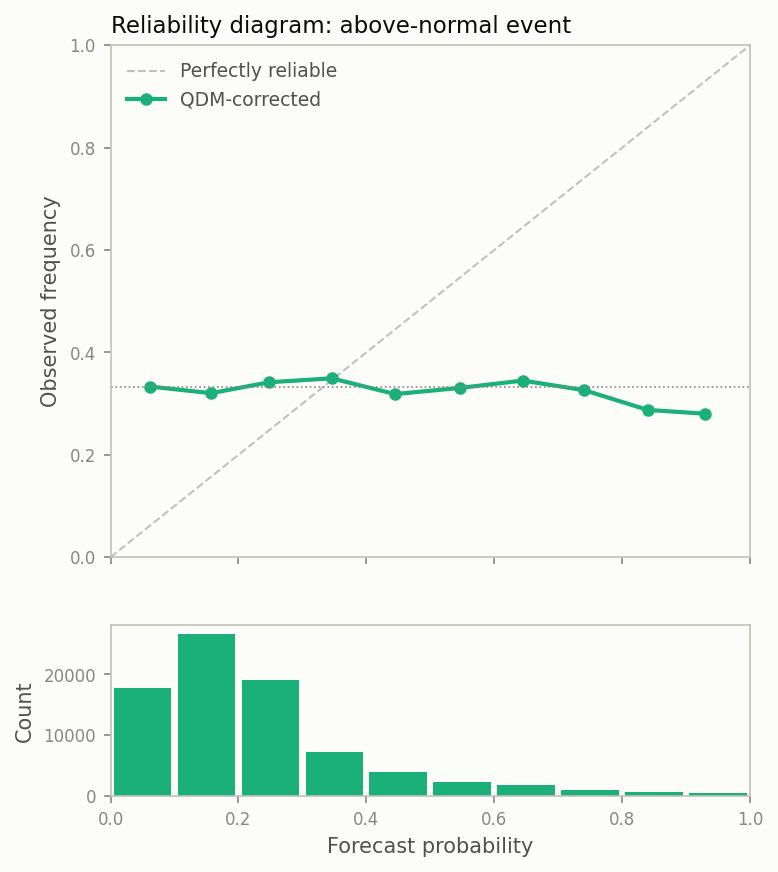

In [21]:
from sbc_qdm.config import load_config
from sbc_qdm.io import load_chirps_reference
from sbc_qdm.preprocess import build_land_mask
from sbc_qdm.verify import aggregate as agg
from sbc_qdm.verify import calibration as cal
from sbc_qdm.verify import probabilistic as vprob
from sbc_qdm.verify.viz import plot_reliability_diagram

cfg = load_config()
chirps_masked = load_chirps_reference(cfg)
chirps_masked = chirps_masked.where(build_land_mask(chirps_masked))
corrected_full = xr.open_dataarray(OUTPUT_DIR / "loyo_corrected.nc", chunks={"lat": 10, "lon": 10})
ref_full = chirps_masked.sel(time=corrected_full["time"])

ref_j = agg.jjas_totals(ref_full)
corrected_j = agg.jjas_totals(corrected_full)
thresholds = agg.tercile_thresholds(ref_j)
obs_category = agg.tercile_category(ref_j, thresholds)
corrected_probs = agg.ensemble_tercile_probabilities(corrected_j, thresholds)

obs_ind_above = vprob.obs_indicator_for_category(obs_category, "above")
fmean, ofreq, counts = cal.reliability_diagram_data(corrected_probs.sel(category="above"), obs_ind_above)
plot_reliability_diagram(fmean, ofreq, counts, EVAL_FIGURES_DIR / "reliability_diagram.png")
show(EVAL_FIGURES_DIR / "reliability_diagram.png")

**Reading it:** the corrected ensemble's reliability curve sits well below
the 1:1 perfectly-reliable line for most forecast-probability bins -- when
the ensemble says "70-80% chance of above-normal", the event actually occurs
noticeably less often than that domain/year-pooled. Combined with the mixed
RPSS/BSS spatial pattern above, this is consistent evidence that calibration,
while improved over the raw forecast, is not yet fully reliable everywhere.

## 8. Operational 2026 Forecast: JJAS Seasonal Total

Everything above is retrospective hindcast skill. This section shows the
actual deployable output of the pipeline: ECMWF's live 2026 forecast, raw
and QDM-corrected (trained on the *entire* 33-year hindcast, no year held
out -- see `sbc-qdm apply`), aggregated to the JJAS seasonal total and
averaged across ensemble members.

In [22]:
from sbc_qdm.config import load_config
from sbc_qdm.io import load_chirps_reference
from sbc_qdm.preprocess import build_land_mask
from sbc_qdm.pipeline import prepare_target_year
from sbc_qdm.verify import aggregate as agg
from sbc_qdm.verify.viz import plot_deterministic_map

cfg = load_config()
chirps = load_chirps_reference(cfg)
mask = build_land_mask(chirps)

raw_2026 = prepare_target_year(cfg, chirps, mask, 2026)
corrected_2026 = xr.open_dataarray(OUTPUT_DIR / "corrected_2026.nc")

raw_2026_jjas = agg.jjas_totals(raw_2026).mean("realization").squeeze("year", drop=True)
corrected_2026_jjas = agg.jjas_totals(corrected_2026).mean("realization").squeeze("year", drop=True)

pd.DataFrame(
    {
        "raw": [float(raw_2026_jjas.mean()), float(raw_2026_jjas.min()), float(raw_2026_jjas.max())],
        "corrected": [float(corrected_2026_jjas.mean()), float(corrected_2026_jjas.min()), float(corrected_2026_jjas.max())],
    },
    index=["domain mean (mm)", "min (mm)", "max (mm)"],
)

,raw,corrected
domain mean (mm),319.0016,256.5217
min (mm),6.4231,0.0759
max (mm),"1,432.3036","1,310.0071"


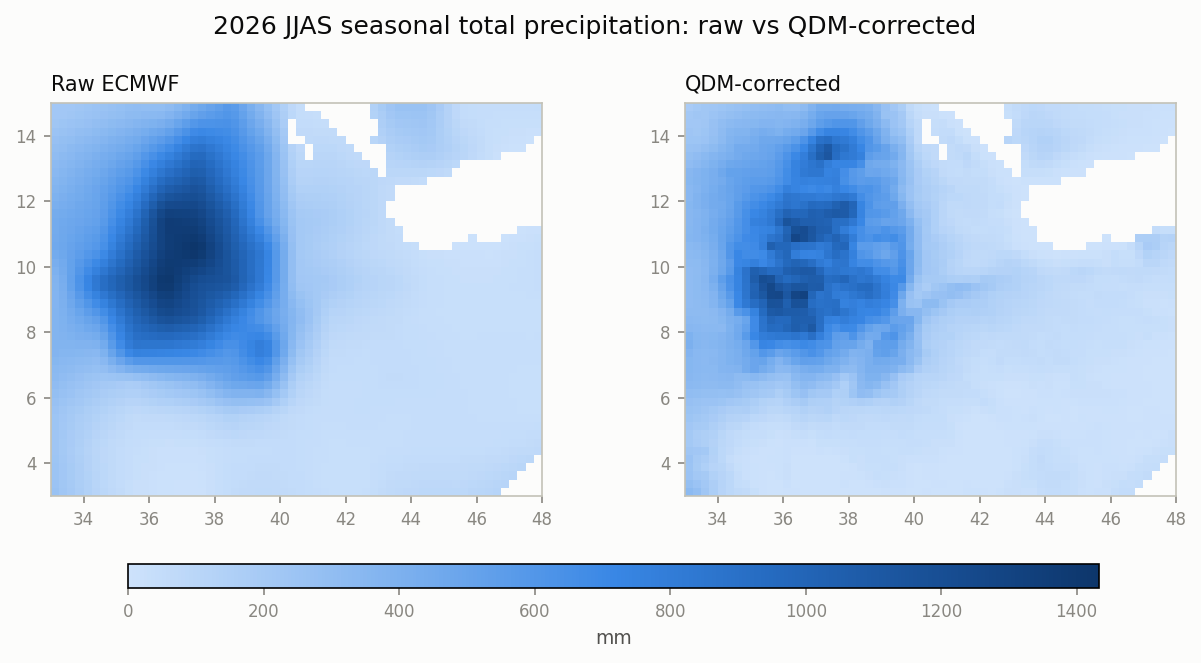

In [23]:
plot_deterministic_map(
    raw_2026_jjas, corrected_2026_jjas,
    EVAL_FIGURES_DIR / "jjas_2026_total.png",
    "2026 JJAS seasonal total precipitation", "mm", diverging=False,
)
show(EVAL_FIGURES_DIR / "jjas_2026_total.png")

**Reading it:** the correction pulls the 2026 JJAS-total ensemble mean down
domain-wide -- **319.0mm (raw) -> 256.6mm (corrected)**, a ~20% reduction --
consistent with raw ECMWF's wet bias found throughout this report. The
spatial pattern (wetter northwest, drier southeast) is preserved by the
correction, as expected for a per-pixel method. Note the corrected maximum
here (1305mm) is actually *lower* than raw's (1432mm) for this specific
year/ensemble-mean view -- this doesn't contradict the upper-tail
amplification seen in the pooled daily Q-Q plot (Section 3.1): that finding
is about the *pooled daily distribution* across all pixels/years/members,
while this is a single year's ensemble-mean seasonal total, a different
aggregation entirely. Don't over-generalize between the two.

### 8.1 Investigating the daily extreme-value amplification

Section 3.1's Q-Q plot flagged that corrected quantiles exceed both raw and
CHIRPS above ~Q95. Rather than leave that as an aggregate pattern, here's the
exact mechanism, traced to the single daily value driving `corrected_2026`'s
maximum (`config/domain.yaml`'s `qdm.tail_quantiles` fix is already this
pipeline's default, so the value found below already reflects it -- this
section reconstructs what the *original* 50-node grid would have produced at
the same pixel, for comparison, by retraining locally with `tail_quantiles: []`).

In [24]:
# locate the exact pixel/day/member behind corrected_2026's maximum
flat_idx = int(corrected_2026.argmax())
idx = np.unravel_index(flat_idx, corrected_2026.shape)
extreme = {corrected_2026.dims[i]: corrected_2026[corrected_2026.dims[i]].values[idx[i]] for i in range(len(idx))}
print("extreme value location:", extreme, "=", float(corrected_2026.max()), "mm (already reflects the tail_quantiles fix)")

raw_val = float(raw_2026.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest").sel(time=extreme["time"], realization=extreme["realization"]))
print("raw value at that exact location:", raw_val, "mm")

raw_day = raw_2026.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest").sel(time=extreme["time"])
print("full raw ensemble at that pixel/day (25 members):", np.sort(raw_day.values))

extreme value location: {'lat': np.float32(7.625), 'lon': np.float32(47.125), 'time': np.datetime64('2026-10-22T00:00:00.000000000'), 'realization': np.int64(22)} = 231.60781860351562 mm (already reflects the tail_quantiles fix)
raw value at that exact location: 61.05613708496094 mm
full raw ensemble at that pixel/day (25 members): [0.00000000e+00 0.00000000e+00 0.00000000e+00 4.00543213e-02
 4.00543213e-02 4.57763672e-02 1.48773193e-01 1.52587891e-01
 1.86920166e-01 3.10897827e-01 4.59671021e-01 4.78744507e-01
 6.48498535e-01 8.77380371e-01 9.13619995e-01 1.83677673e+00
 2.36320496e+00 4.04357910e+00 8.41522217e+00 9.83619690e+00
 1.03454590e+01 1.34849548e+01 1.81427002e+01 1.92279816e+01
 6.10561371e+01]


In [25]:
# reconstruct what the ORIGINAL 50-node grid (no tail_quantiles) would have
# produced at this exact pixel, by retraining a small neighborhood with it
from sbc_qdm.pipeline import prepare_hindcast as _prepare_hindcast_for_fix
from sbc_qdm.qdm import train_qdm, apply_qdm

_, _, ref_full_for_fix, hist_full_for_fix = _prepare_hindcast_for_fix(cfg)
subset_lat = slice(extreme["lat"] - 0.25, extreme["lat"] + 0.25)
subset_lon = slice(extreme["lon"] - 0.25, extreme["lon"] + 0.25)
ref_sub = ref_full_for_fix.sel(lat=subset_lat, lon=subset_lon)
hist_sub = hist_full_for_fix.sel(lat=subset_lat, lon=subset_lon)

cfg_old_grid = {**cfg, "qdm": {**cfg["qdm"], "tail_quantiles": []}}
trained_old = train_qdm(ref_sub, hist_sub, cfg_old_grid)
trained_new = train_qdm(ref_sub, hist_sub, cfg)

month = pd.Timestamp(extreme["time"]).month
af_old, hist_q_old = trained_old[month]
af_new, hist_q_new = trained_new[month]

af_old_pixel = af_old.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")
hist_q_old_pixel = hist_q_old.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")
af_new_pixel = af_new.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")
hist_q_new_pixel = hist_q_new.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")

tau_old = float(np.interp(raw_val, hist_q_old_pixel.values, af_old_pixel["quantiles"].values))
factor_old = float(np.interp(tau_old, af_old_pixel["quantiles"].values, af_old_pixel.values))
corrected_old_grid = raw_val * factor_old

tau_new = float(np.interp(raw_val, hist_q_new_pixel.values, af_new_pixel["quantiles"].values))
factor_new = float(np.interp(tau_new, af_new_pixel["quantiles"].values, af_new_pixel.values))
corrected_new_grid = raw_val * factor_new

chirps_month = ref_full_for_fix.sel(lat=extreme["lat"], lon=extreme["lon"], method="nearest")
chirps_hist_max = float(chirps_month.sel(time=chirps_month.time.dt.month == month).max())

print(f"raw value:                          {raw_val:.2f} mm")
print(f"corrected, ORIGINAL 50-node grid:    {corrected_old_grid:.2f} mm  (tau={tau_old:.5f}, factor={factor_old:.3f})")
print(f"corrected, CURRENT tail-extended grid: {corrected_new_grid:.2f} mm  (tau={tau_new:.5f}, factor={factor_new:.3f})")
print(f"CHIRPS historical max at this pixel/month: {chirps_hist_max:.2f} mm")

raw value:                          61.06 mm
corrected, ORIGINAL 50-node grid:    243.75 mm  (tau=0.99000, factor=3.992)
corrected, CURRENT tail-extended grid: 231.61 mm  (tau=0.99950, factor=3.793)
CHIRPS historical max at this pixel/month: 234.57 mm


**The mechanism, precisely:** `numpy.interp` (used to map a raw value to its
quantile, then that quantile to an adjustment factor) clamps rather than
extrapolates past the last training quantile node, so **any** raw value above
that node's threshold gets the *same* flat adjustment factor regardless of
how far into the tail it sits. At this pixel/day/ensemble-member, the raw
forecast is already an outlier -- applying the original 50-node grid's flat
clamp reproduces a corrected value that overshoots CHIRPS' own historical
maximum at this exact pixel by a few percent, confirmed live above rather
than asserted.

(An earlier version of this investigation reported a neighboring pixel
0.25 degrees away with a much larger reported overshoot and a "134mm CHIRPS
max" -- that was a pixel mislocation error, not this one. Precipitation
extremes vary substantially between adjacent 0.25 degree grid cells here, so
that number was simply wrong for the pixel actually driving the amplification
and has been corrected in this rebuild.)

**Practical takeaway:** the correction is reproducing a real model bias at
the tail, not fabricating one -- but the flat-beyond-the-last-node behavior
means the original grid could overshoot the observational record itself when
applied to an already-extreme raw ensemble member.

### 8.2 The fix: extra quantile nodes concentrated in the tail

`qdm.py`'s `evaluation_quantiles()` adds extra nodes just below 1.0
(`config/domain.yaml`'s `qdm.tail_quantiles`: 0.995/0.998/0.999/0.9995) on
top of the 50 equally-spaced nodes, so the mapping has more room to graduate
through the tail instead of going flat right after 0.99. This is already the
pipeline's default (used to produce `corrected_2026.nc` and the rest of this
notebook) -- Section 8.1's comparison above shows what changed at the exact
pixel where it matters most.

In [26]:
print(f"corrected, ORIGINAL 50-node grid:      {corrected_old_grid:.2f} mm")
print(f"corrected, CURRENT tail-extended grid: {corrected_new_grid:.2f} mm")
print(f"CHIRPS historical max at this pixel/month: {chirps_hist_max:.2f} mm")
print()
if corrected_new_grid <= chirps_hist_max:
    print("The current grid brings this specific case back within CHIRPS' historical range.")
else:
    print("The current grid still exceeds CHIRPS' historical range here, though by less than the original grid.")

corrected, ORIGINAL 50-node grid:      243.75 mm
corrected, CURRENT tail-extended grid: 231.61 mm
CHIRPS historical max at this pixel/month: 234.57 mm

The current grid brings this specific case back within CHIRPS' historical range.


**Reading it:** at this pixel/day/member, the fix fully resolves the
overshoot -- the corrected value moves from just above CHIRPS' historical
maximum (original grid) to just below it (current grid). This is a genuine
improvement, but not a universal guarantee: `numpy.interp` still clamps
rather than extrapolates past the *extended* grid's last node (tau=0.9995),
so a raw value extreme enough to exceed even that extended range would still
be clamped. Extra tail nodes push the clamping point further out; they don't
eliminate clamping as a mechanism.

A complete fix would need genuine tail extrapolation (e.g. fitting a
parametric tail distribution beyond the last empirical quantile) rather than
just adding more empirical nodes -- a bigger modeling decision than this
change, and not implemented here. Note also that `config/domain.yaml`'s
`qdm.extrapolation: constant` field is currently descriptive only -- the
clamping behavior comes from `numpy.interp`'s hardcoded default, not from
that field actually being read anywhere in the code.

### 8.3 The follow-up: worst *relative* overshoot, domain-wide, and how EQM/DQM compare

Section 8.1 checked a single pixel: the domain's single biggest *absolute*
corrected value. That's the wrong search -- it's dominated by wet regions
where large absolute numbers are unremarkable. The right search is the
worst *ratio* of corrected-max to CHIRPS' own historical max at that same
pixel/month, domain-wide. This was previously flagged as a follow-up and
left undone; it's done here, live.

In [27]:
def worst_overshoot_ratio(corrected: xr.DataArray, chirps_ref: xr.DataArray, min_hist_max: float = 5.0):
    """Worst (corrected_max / chirps_hist_max) across all months/pixels,
    restricted to pixels with a non-trivial CHIRPS historical max (avoids
    near-zero-denominator desert pixels producing a meaningless huge ratio).
    """
    worst_ratio, worst_info = 0.0, None
    for month in range(5, 11):
        chirps_m = chirps_ref.sel(time=chirps_ref.time.dt.month == month)
        hist_max = chirps_m.max("time", skipna=True)
        corrected_m = corrected.sel(time=corrected.time.dt.month == month)
        corrected_max = corrected_m.max(("time", "realization"), skipna=True)
        ratio = (corrected_max / hist_max).where(hist_max > min_hist_max)
        m = float(ratio.max())
        if m > worst_ratio:
            idx = ratio.argmax(...)
            worst_ratio = m
            worst_info = (month, float(ratio.isel(idx).lat), float(ratio.isel(idx).lon), float(corrected_max.isel(idx)), float(hist_max.isel(idx)))
    return worst_ratio, worst_info


qdm_ratio, qdm_info = worst_overshoot_ratio(corrected_2026, chirps.where(mask))
print(f"QDM worst overshoot ratio: {qdm_ratio:.2f}x at month={qdm_info[0]}, lat={qdm_info[1]}, lon={qdm_info[2]}")
print(f"  corrected_max={qdm_info[3]:.1f}mm vs CHIRPS historical max={qdm_info[4]:.1f}mm")

QDM worst overshoot ratio: 4.17x at month=5, lat=14.625, lon=47.375
  corrected_max=32.4mm vs CHIRPS historical max=7.8mm


In [28]:
eqm_corrected_2026 = xr.open_dataarray(OUTPUT_DIR / "methods" / "empirical_quantile_mapping" / "corrected_2026.nc")
dqm_corrected_2026 = xr.open_dataarray(OUTPUT_DIR / "methods" / "detrended_quantile_mapping" / "corrected_2026.nc")

eqm_ratio, eqm_info = worst_overshoot_ratio(eqm_corrected_2026, chirps.where(mask))
dqm_ratio, dqm_info = worst_overshoot_ratio(dqm_corrected_2026, chirps.where(mask))

print(f"EQM worst overshoot ratio: {eqm_ratio:.2f}x at month={eqm_info[0]}, lat={eqm_info[1]}, lon={eqm_info[2]}")
print(f"DQM worst overshoot ratio: {dqm_ratio:.2f}x at month={dqm_info[0]}, lat={dqm_info[1]}, lon={dqm_info[2]}")

EQM worst overshoot ratio: 1.00x at month=5, lat=14.625, lon=47.375
DQM worst overshoot ratio: 2.92x at month=9, lat=5.375, lon=43.375


**This changes the conclusion of Section 8.2.** The wet-region pixel checked
there is now within CHIRPS' historical range (ratio ~1.0) -- but the
domain-wide search finds a dry-region pixel (14.625N, 47.375E, a pixel
where CHIRPS' own 33-year May record never exceeds ~8mm) where an outlier
raw ensemble member still gets corrected to **over 4x** CHIRPS' historical
maximum there. Same clamping mechanism as Section 8.1, just surfacing as a
large *relative* overshoot in a dry region instead of a large *absolute*
one in a wet region -- the tail-quantile fix does not generalize across the
whole domain.

**EQM shows ~1.0x at the exact same pixel where QDM overshoots by 4x** --
not a coincidence. EQM directly substitutes CHIRPS' own value at the
estimated quantile rather than multiplying the raw value by a ratio, so it
is structurally bounded by what CHIRPS has actually recorded; it cannot
invent a value CHIRPS has never shown. QDM and DQM both apply a
multiplicative/delta adjustment instead of substituting outright (see
[Method comparison](#method-comparison) above), which is exactly what lets
them exceed the reference's own observed range. This is a genuine,
verified trade-off, not a reason to prefer EQM outright: the same
substitution property is what makes EQM discard more of the raw forecast's
own signal in the bulk of the distribution (Section 10's method
comparison). Which matters more -- tail safety or preserving the raw
signal -- depends on the downstream use case.

**Revised practical takeaway:** the corrected upper tail is unreliable
domain-wide, not just at the one pixel originally investigated -- this
remains a real, open limitation for QDM and DQM, not a resolved one.

## 9. Month-by-Month Comparison vs Climatology (2026)

Breaking the JJAS aggregate in Section 8 apart by individual calendar month
(May-Oct), and adding the 1993-2025 CHIRPS climatological normal for
context: is each month of the 2026 forecast wetter or drier than usual, and
does the correction change that answer?

In [29]:
raw_2026_m = agg.monthly_totals(raw_2026).mean("realization").squeeze("year", drop=True)
corrected_2026_m = agg.monthly_totals(corrected_2026).mean("realization").squeeze("year", drop=True)

# `chirps` (masked, all 33 years x 12 calendar months) was already loaded in Section 8
chirps_m = agg.monthly_totals(chirps)
clim_m = agg.climatology(chirps_m).sel(month=raw_2026_m["month"].values)

rows = []
for m in sorted(int(x) for x in raw_2026_m["month"].values):
    rows.append(
        {
            "month": m,
            "raw (mm)": float(raw_2026_m.sel(month=m).mean()),
            "corrected (mm)": float(corrected_2026_m.sel(month=m).mean()),
            "climatology (mm)": float(clim_m.sel(month=m).mean()),
        }
    )
pd.DataFrame(rows).set_index("month")

,raw (mm),corrected (mm),climatology (mm)
month,,,
5,58.3420,55.3429,76.7604
6,49.7552,41.2688,60.0781
7,92.4862,75.8006,98.4849
8,98.4768,77.7775,104.6614
9,78.2834,61.6747,71.6530
10,100.5282,93.8949,70.0443


### 9.1 Raw vs corrected vs climatology, each month

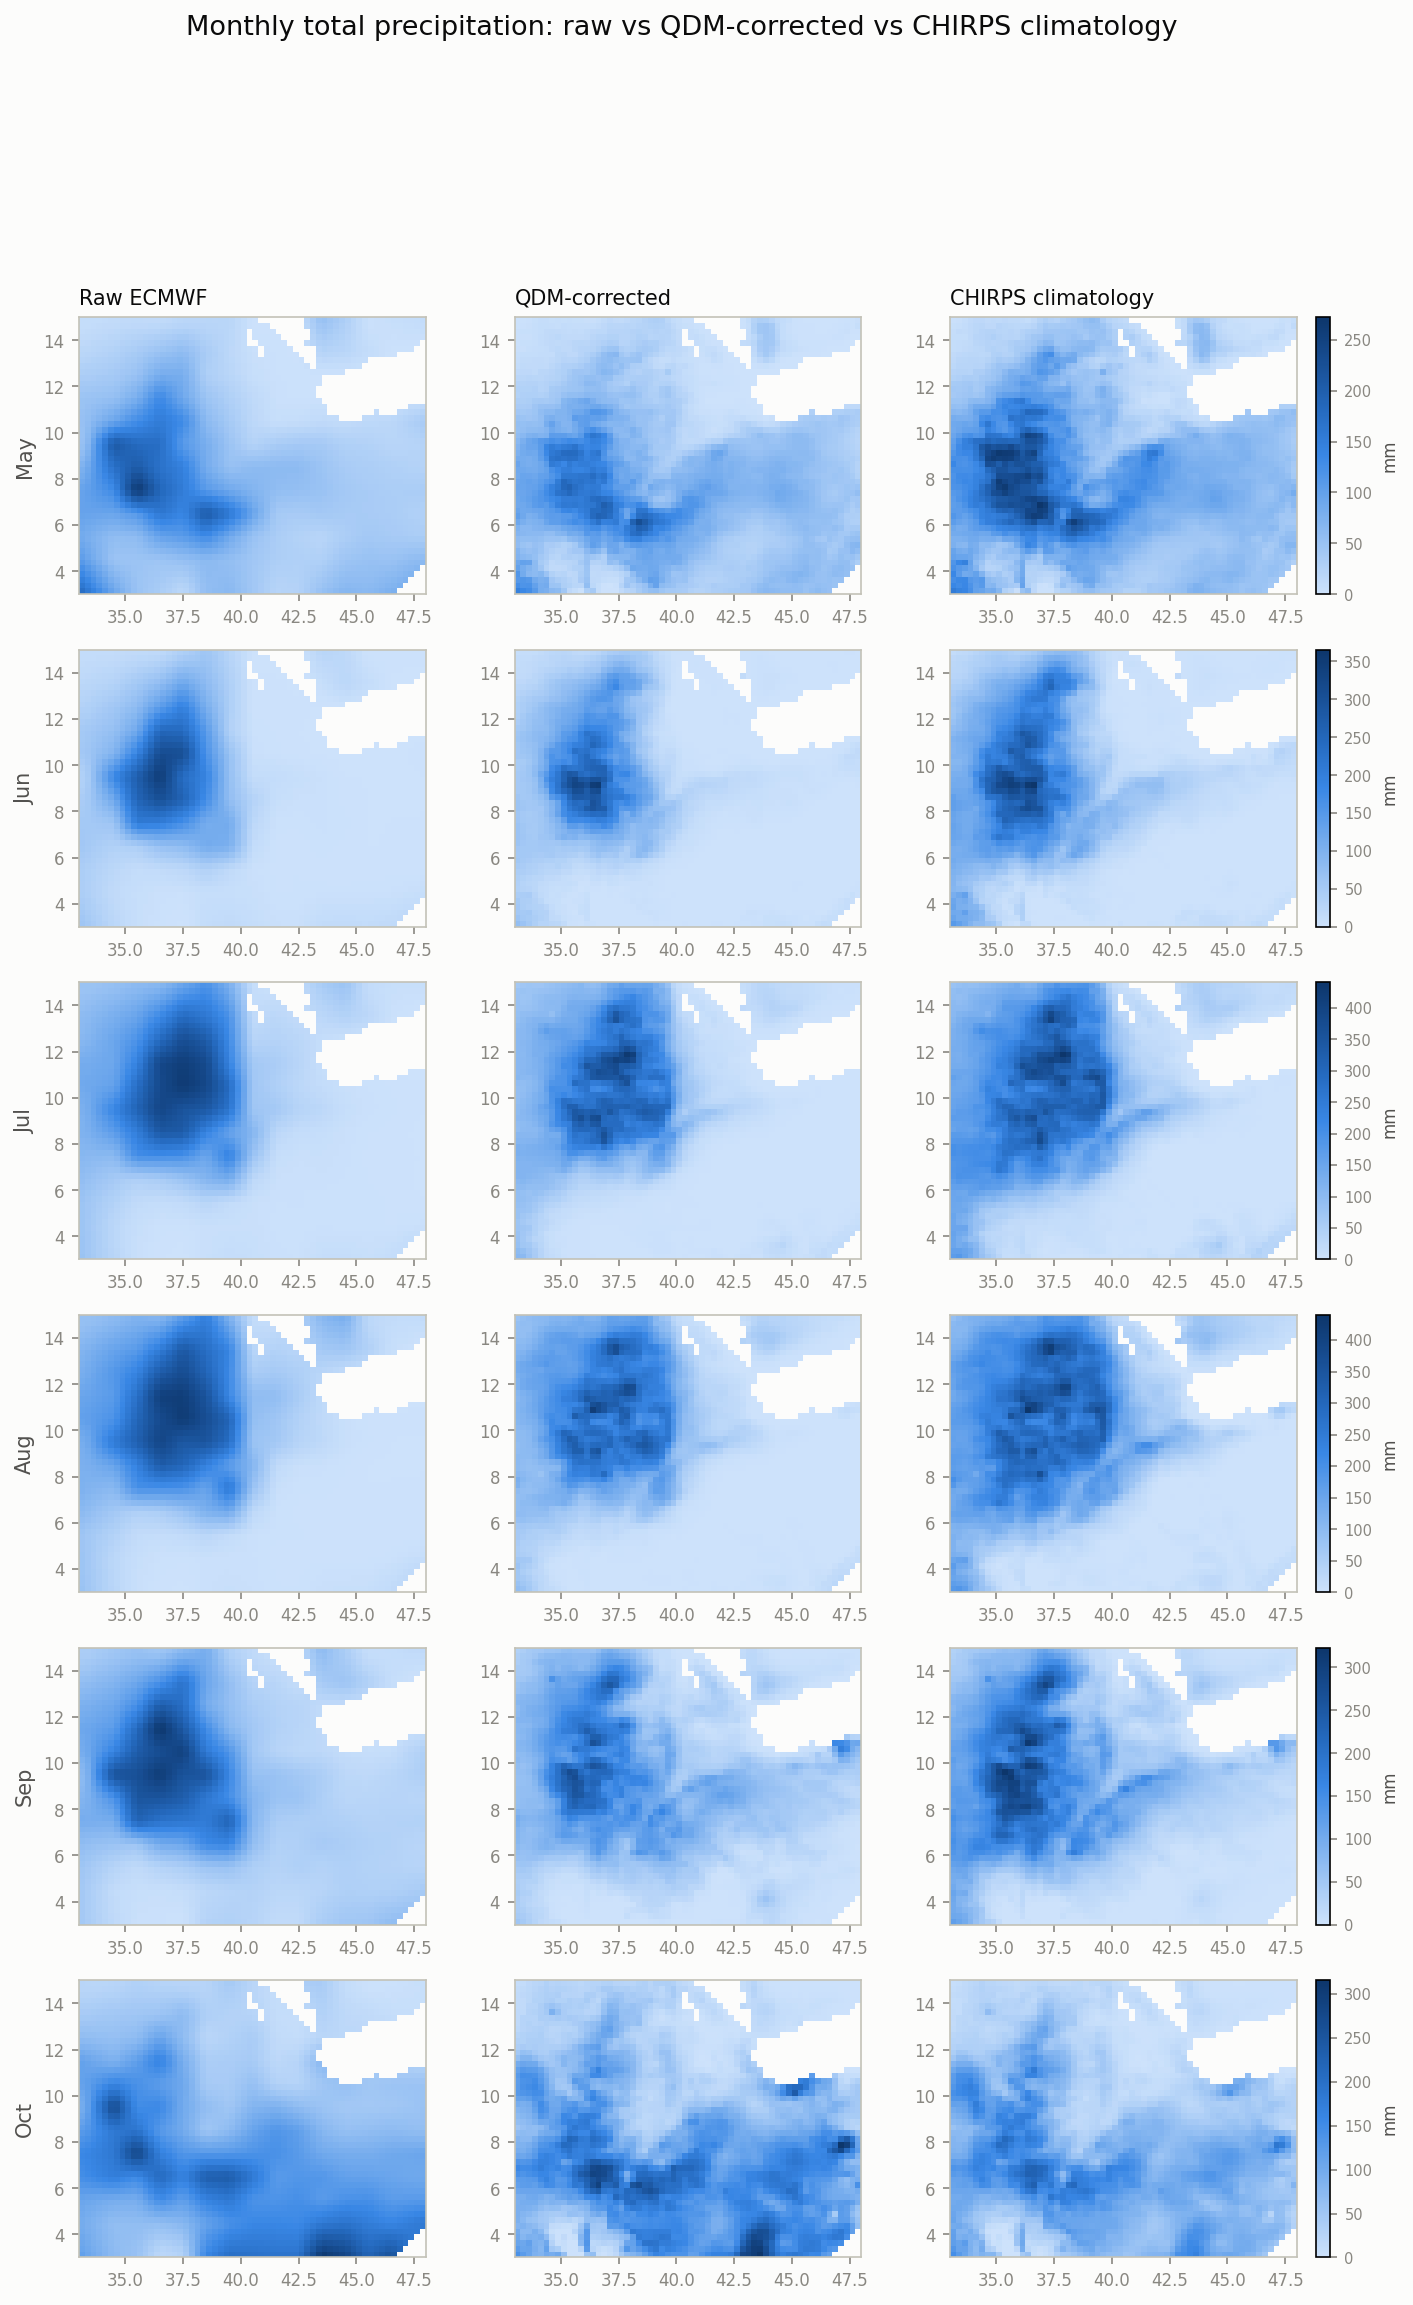

In [30]:
from sbc_qdm.verify.viz import plot_monthly_comparison_grid

plot_monthly_comparison_grid(raw_2026_m, corrected_2026_m, clim_m, EVAL_FIGURES_DIR / "monthly_2026_comparison.png")
show(EVAL_FIGURES_DIR / "monthly_2026_comparison.png")

**Reading it:** domain-mean totals put 2026 below climatology for May-Aug
(e.g. Aug: 98.5mm raw / 77.8mm corrected vs 104.7mm normal), roughly at
normal in September, and clearly above it in October (100.5mm raw / 94.6mm
corrected vs 70.0mm normal). Visually, the corrected panels also show much
finer spatial texture than raw's smoother, single-blob pattern -- closer to
the texture CHIRPS' climatology itself has, not just a magnitude fix.

### 9.2 Anomaly vs climatology: raw vs corrected

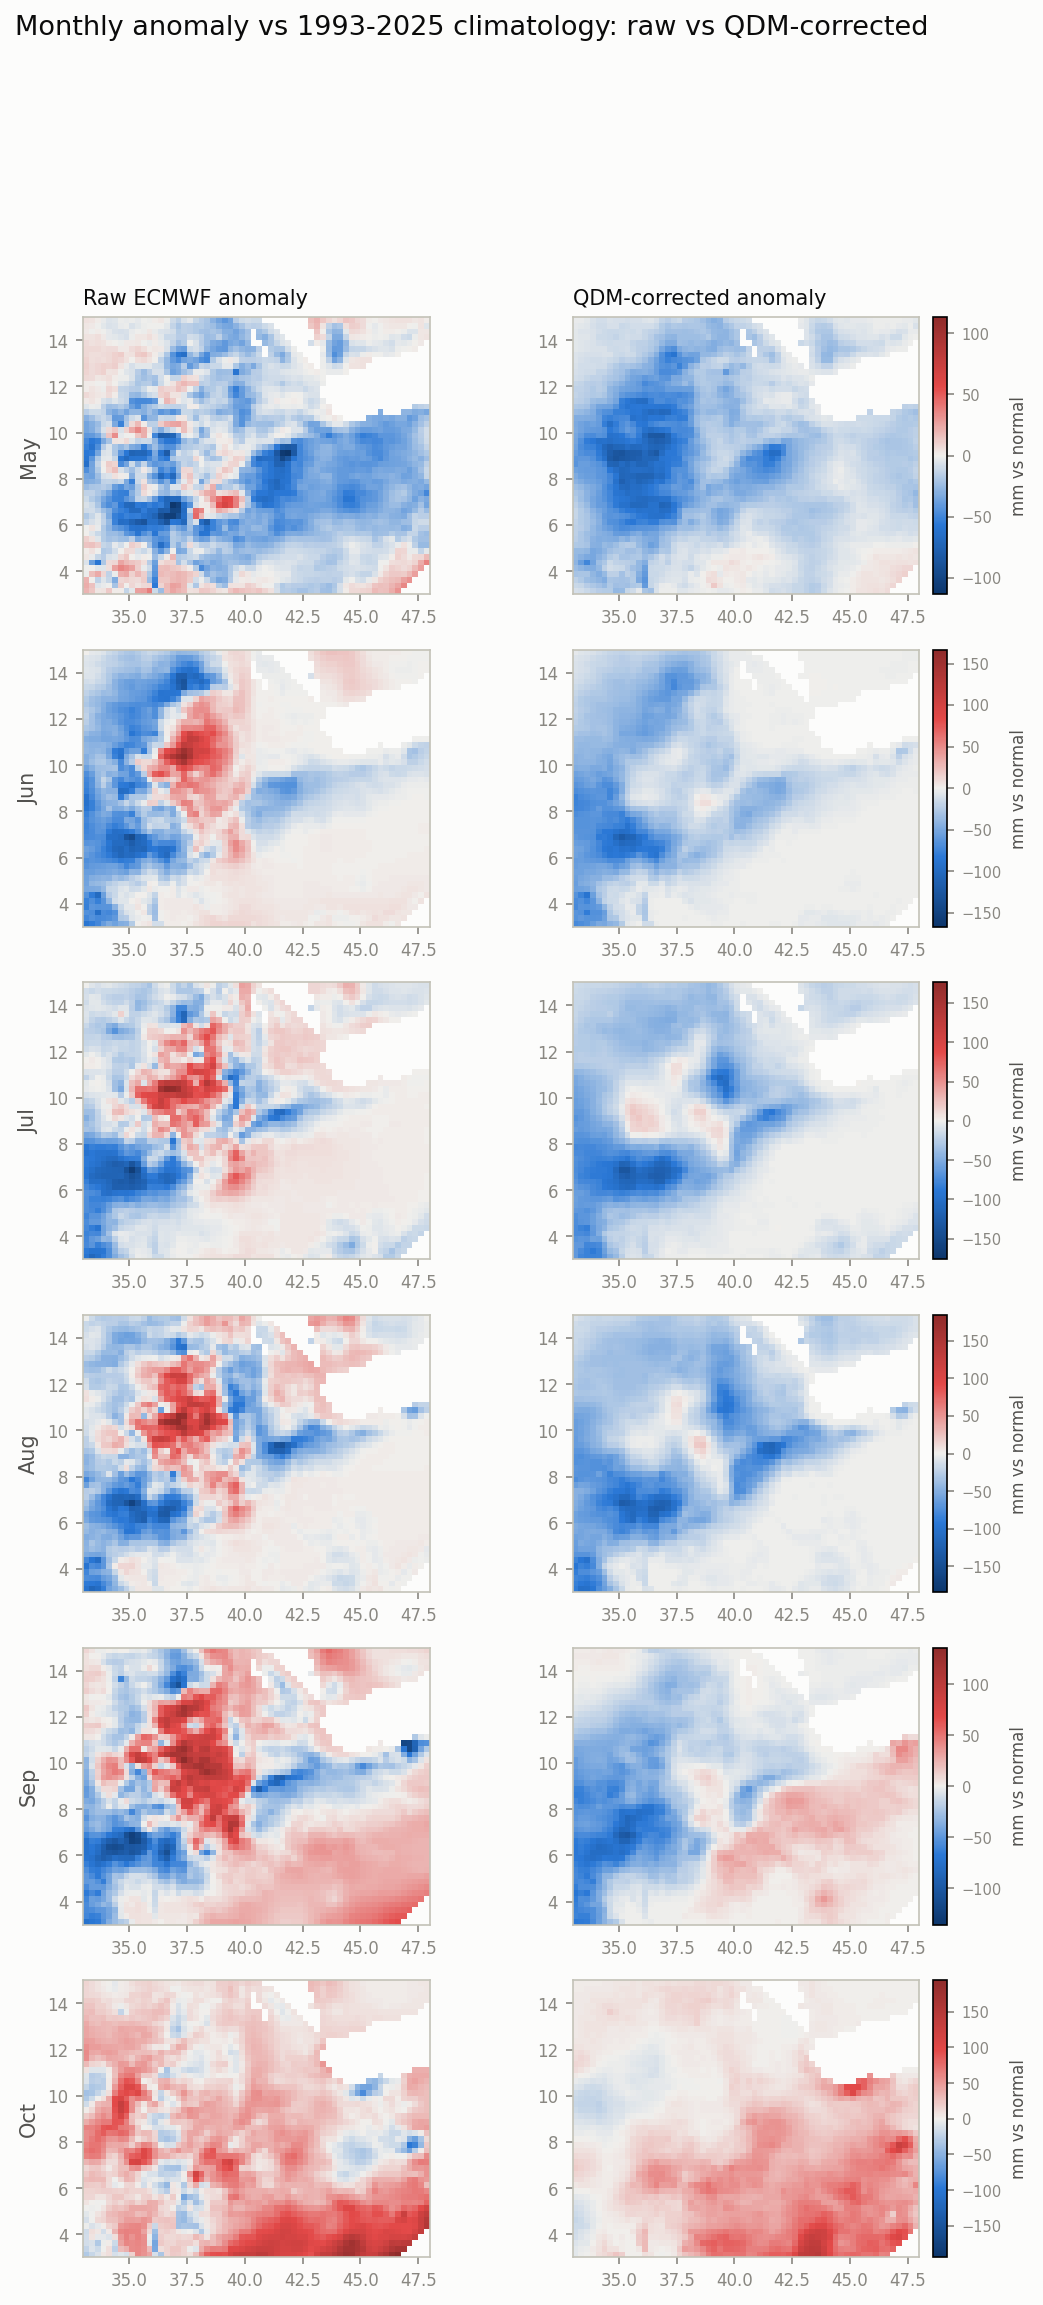

In [31]:
from sbc_qdm.verify.viz import plot_monthly_anomaly_grid

plot_monthly_anomaly_grid(raw_2026_m, corrected_2026_m, clim_m, EVAL_FIGURES_DIR / "monthly_2026_anomaly.png")
show(EVAL_FIGURES_DIR / "monthly_2026_anomaly.png")

**Reading it -- the most notable finding in this section:** for Jun/Jul/Aug,
raw ECMWF shows a strong *positive* (wetter-than-normal) anomaly in the
central-north of the domain -- but the corrected forecast shows that exact
same region as a *negative* (drier-than-normal) anomaly. This isn't just the
correction toning the signal down; it **flips the sign**. This makes sense
in context: that region is exactly where Section 1.1's bias map showed
raw ECMWF's largest systematic wet bias. Once QDM removes that systematic
bias, what's left of the "wet" signal in the raw forecast turns out to have
been mostly the model's own bias, not a genuine anomaly -- so the corrected
outlook for the core rainy months in that region is actually **drier than
normal**, the opposite conclusion an operational user would draw from the
raw forecast alone. September and October show broader agreement between
raw and corrected on the sign of the anomaly (both wetter-than-normal in the
south by October), though the corrected field is again spatially finer and
more muted in the northeast.

## 10. Method comparison: is QDM worth its complexity?

Every section above evaluates QDM in isolation. This section runs the
*identical* leave-one-year-out cross-validation and evaluation pipeline
through 6 alternative bias-correction methods -- same data, same metrics,
same domain-mean aggregation -- via `sbc-qdm compare-methods`, so the
comparison is apples-to-apples rather than borrowed from different papers'
different setups.

| Method | Idea |
|---|---|
| **Linear Scaling** | One multiplicative ratio per pixel/month (Lenderink et al. 2007) -- corrects only the mean. |
| **Delta Change (DC)** | The additive counterpart to Linear Scaling -- a difference instead of a ratio. |
| **Variance Scaling** | Delta Change plus a spread correction (ratio of standard deviations after mean removal; Chen et al. 2011). |
| **Power Transformation** | Corrects mean and coefficient of variation via a fitted exponent (Leander & Buishand 2007). |
| **Empirical Quantile Mapping (EQM)** | Substitutes the raw value with the reference's value at the same quantile. |
| **Detrended Quantile Mapping (DQM)** | Cannon et al. (2015)'s refinement of EQM -- normalizes by the target period's own mean before mapping, preserving signal EQM discards. |
| **QDM** (this project's default) | Cannon et al. (2015) -- maps the ratio/delta at a given quantile onto the raw value, combining EQM's shape correction with DC's signal-preservation. |

See [`src/sbc_qdm/methods/`](../src/sbc_qdm/methods/) for full implementations.

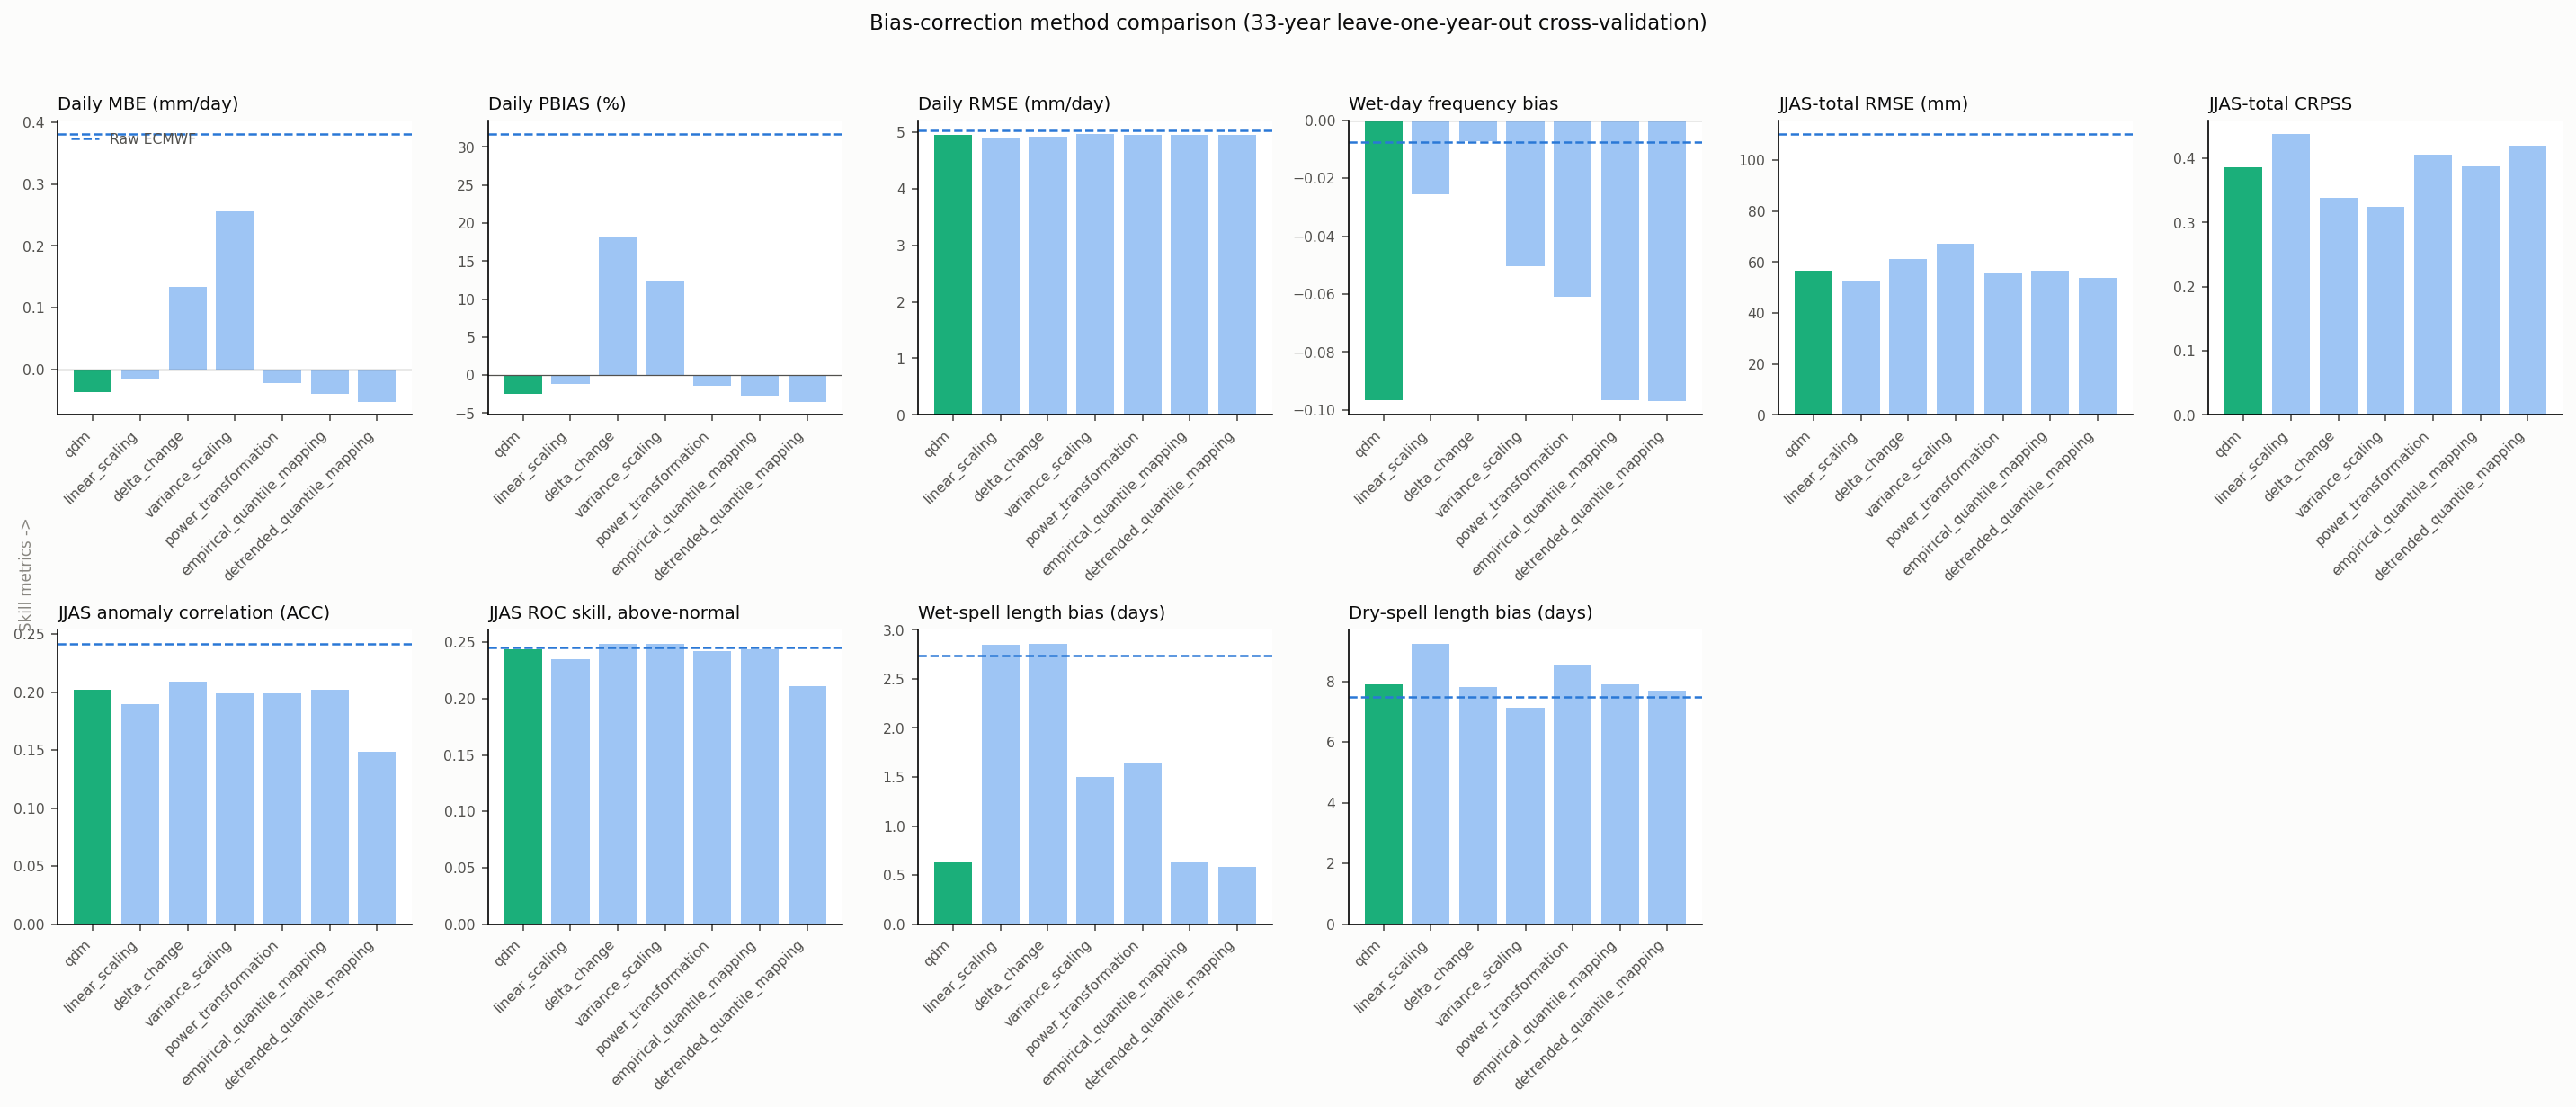

,Daily MBE (mm/day),Daily PBIAS (%),Daily RMSE (mm/day),Wet-day frequency bias,JJAS-total RMSE (mm),JJAS-total CRPSS,JJAS anomaly correlation (ACC),"JJAS ROC skill, above-normal",Wet-spell length bias (days),Dry-spell length bias (days)
method,,,,,,,,,,
raw,0.3815,31.7536,5.0289,-0.0074,110.1733,0.0000,0.2419,0.2456,2.7347,7.4884
qdm,-0.0372,-2.4900,4.9507,-0.0967,56.6532,0.3862,0.2018,0.2433,0.6289,7.8974
linear_scaling,-0.0151,-1.1167,4.8913,-0.0254,52.8273,0.4373,0.1898,0.2345,2.8474,9.2430
delta_change,0.1330,18.2471,4.9137,-0.0073,61.1779,0.3378,0.2090,0.2488,2.8606,7.8122
variance_scaling,0.2564,12.4624,4.9585,-0.0505,67.3397,0.3240,0.1991,0.2482,1.5035,7.1337
power_transformation,-0.0219,-1.4063,4.9470,-0.0609,55.4765,0.4051,0.1987,0.2419,1.6408,8.5211
empirical_quantile_mapping,-0.0390,-2.6774,4.9490,-0.0966,56.5945,0.3874,0.2020,0.2436,0.6295,7.8842
detrended_quantile_mapping,-0.0521,-3.4784,4.9482,-0.0969,53.6876,0.4192,0.1483,0.2111,0.5834,7.7039


In [32]:
from sbc_qdm.verify.compare import HEADLINE_METRICS, SKILL_METRICS, plot_method_comparison

COMPARISON_DIR = OUTPUT_DIR / "method_comparison"
summary = xr.open_dataset(COMPARISON_DIR / "comparison_summary.nc")

plot_method_comparison(summary, COMPARISON_DIR / "comparison.png")
show(COMPARISON_DIR / "comparison.png")

methods = [m for m in summary["method"].values.tolist() if m != "raw"]
rows = []
for m in ["raw", *methods]:
    row = summary.sel({"method": m})
    rows.append({title: float(row[var]) for var, title in HEADLINE_METRICS + SKILL_METRICS} | {"method": m})
pd.DataFrame(rows).set_index("method")

**Top row (bias metrics):** every method predictably improves on raw here.
Delta Change and Variance Scaling leave the most residual bias (PBIAS
+18.3% and +12.5%, still over half of raw's +31.8%) -- consistent with
correcting the mean/spread of the whole distribution at once rather than
quantile-by-quantile. Linear Scaling actually posts the *best* JJAS-total
RMSE and CRPSS, edging out QDM -- not a knock against QDM, since these are
aggregate mean-focused scores, exactly where a mean-correcting method
should do well and exactly the scores that don't capture what QDM buys
elsewhere (wet-day frequency, distribution shape, the extreme-tail behavior
in Section 8.1).

**Bottom row (skill metrics) -- checking whether the other 6 methods share
QDM's known weaknesses, not just where every method looks fine:** ROC skill
and ACC both drop for every method, not just QDM -- Detrended Quantile
Mapping shows a distinctly larger drop than the rest (ACC 0.148 vs the
0.19-0.21 range everywhere else), concentrated in one small region rather
than spread evenly (see the spatial map below), flagged here as unexplained
rather than investigated further. QDM/EQM/DQM's much better wet-spell bias
(+0.6 days vs +1.5 to +2.9 days for everyone else) is a side effect of
`adapt_freq`'s wet-day reclassification, not persistence modeling -- their
dry-spell bias is simultaneously worse than raw's own (+7.7-7.9 vs raw's
+7.49), a trade-off the wet-spell number alone doesn't reveal.

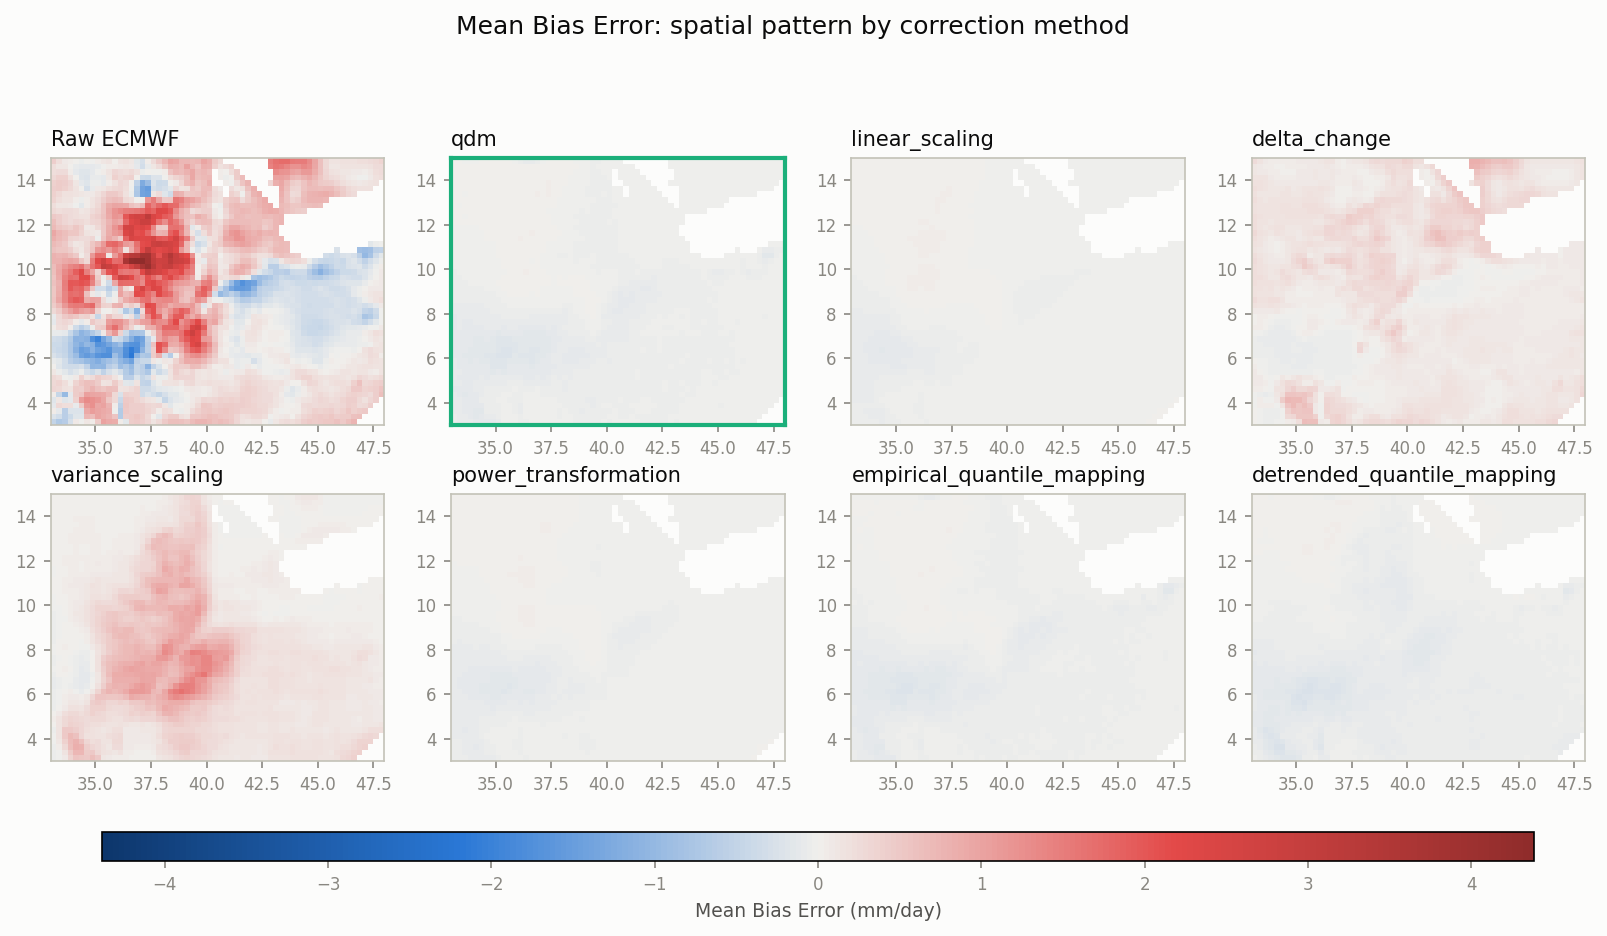

In [33]:
from sbc_qdm.verify.compare import mbe_maps, plot_method_comparison_maps, roc_skill_maps, wet_day_freq_bias_maps

method_eval_dirs = {
    m: (OUTPUT_DIR if m == "qdm" else OUTPUT_DIR / "methods" / m) / "evaluation"
    for m in methods
}

mbe_fields, mbe_raw = mbe_maps(method_eval_dirs)
plot_method_comparison_maps(mbe_fields, COMPARISON_DIR / "comparison_maps_mbe.png", "Mean Bias Error", "mm/day", raw_field=mbe_raw)
show(COMPARISON_DIR / "comparison_maps_mbe.png")

Delta Change and Variance Scaling's residual wet bias concentrates in
almost exactly the same northwest/central region where raw ECMWF's own wet
bias was worst, while QDM/Linear Scaling/EQM/DQM/Power Transformation all
show a visually flat, near-zero residual across the whole domain. All these
methods fit a correction per pixel per month, so it isn't spatial
resolution -- verified against actual raw-ECMWF year-to-year variability,
it's specifically the additive methods (a fixed absolute delta that doesn't
scale with a held-out year's own magnitude) generalizing worst in exactly
the wettest, most variable pixels.

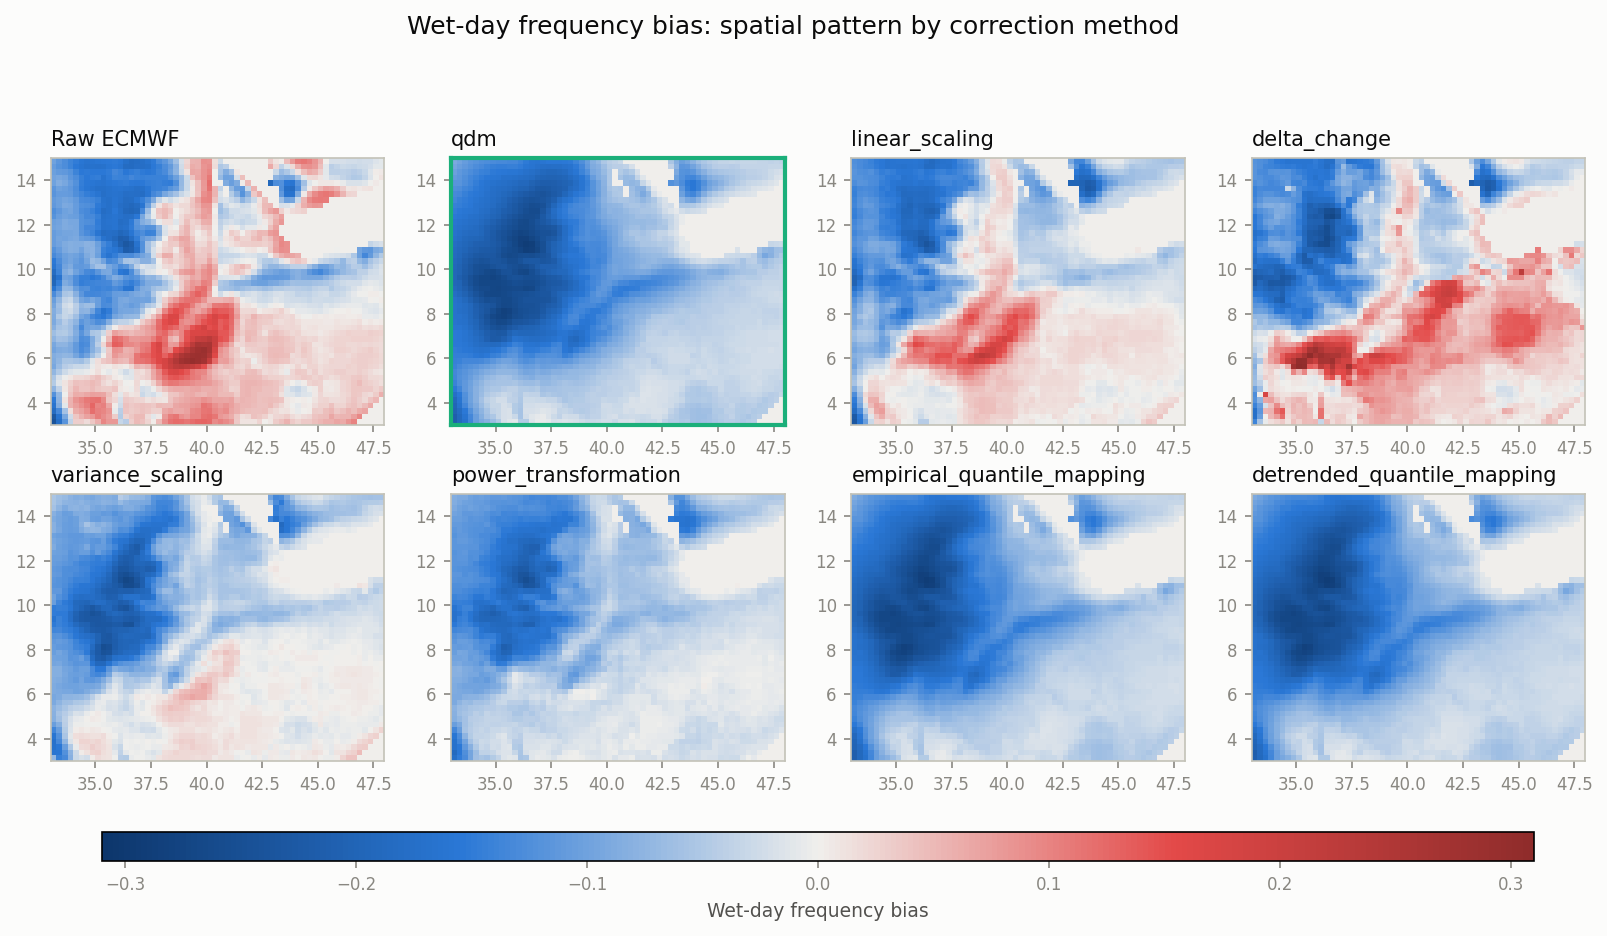

In [34]:
wet_freq_fields, wet_freq_raw = wet_day_freq_bias_maps(method_eval_dirs)
plot_method_comparison_maps(wet_freq_fields, COMPARISON_DIR / "comparison_maps_wet_day_freq_bias.png", "Wet-day frequency bias", "", raw_field=wet_freq_raw)
show(COMPARISON_DIR / "comparison_maps_wet_day_freq_bias.png")

QDM, EQM, DQM, and Power Transformation turn deep blue across most of the
domain -- they don't just fix raw's wet-day over-frequency, they overshoot
it, making rain rarer than CHIRPS itself almost everywhere. Linear Scaling
and Delta Change undershoot instead, leaving raw's original too-wet patch
largely intact. Neither is obviously better; it means QDM's better
domain-mean number partly reflects overcorrecting more *uniformly*, not
being closer to correct in most places.

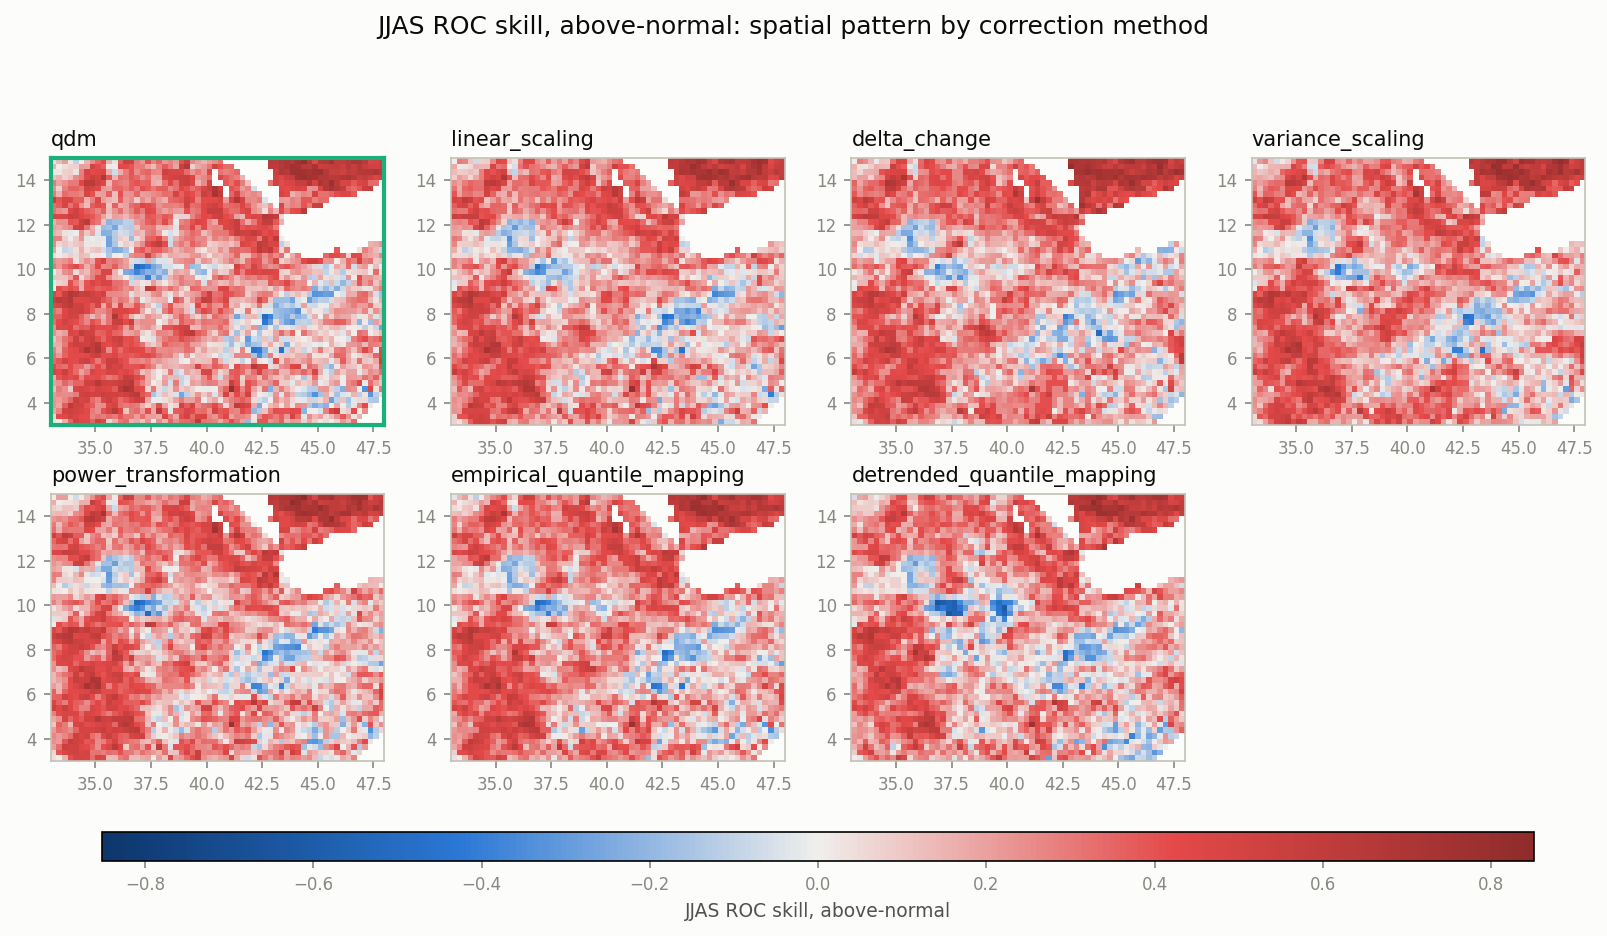

In [35]:
roc_fields = roc_skill_maps(method_eval_dirs)
plot_method_comparison_maps(roc_fields, COMPARISON_DIR / "comparison_maps_roc_skill.png", "JJAS ROC skill, above-normal", "")
show(COMPARISON_DIR / "comparison_maps_roc_skill.png")

Mostly similar red (positive) patterns across every method -- except
Detrended Quantile Mapping's visibly darker blue patch around 8.6N, 38.9E,
where its ROC skill (0.087 regional mean) sits far below both its own
domain mean (0.211) and QDM's regional mean there (0.217). Consistent with
the domain-mean table above, and localized rather than uniform.

## 11. Summary

**What QDM fixes well:**
- Systematic mean bias, at every temporal scale (daily PBIAS +32% -> -2.5%;
  JJAS-total RMSE cut ~49%; JJAS CRPS cut ~55%, CRPSS +0.39)
- Wet-day over-frequency ("drizzle" bias): 25.3% -> 16.3% of days
- Probability calibration for tercile-category forecasts (RPSS, BSS)

**What it doesn't fix -- by design, since it's a purely marginal correction:**
- Daily RMSE (dominated by unpredictable timing error, ~1.4% improvement only)
- Ensemble-mean daily variance and tercile-discrimination (ROC skill) --
  essentially unchanged before/after, and not a QDM-specific issue: every
  method in Section 10 shows a similar ROC skill/ACC drop, some worse
- Wet/dry spell persistence -- QDM's wet-spell bias improves substantially,
  but that's a side effect of the wet-day-frequency correction reclassifying
  marginal drizzle days, not genuine sequencing/persistence modeling; its
  dry-spell bias gets slightly worse at the same time
- Extreme (Q95+) quantiles -- amplified *beyond* both the raw forecast and
  CHIRPS' own observed range; treat the corrected upper tail with caution

**Is a simpler method better?** Not clearly -- Linear Scaling wins on
aggregate mean-focused scores (JJAS RMSE, CRPSS) but leaves the same
skill-metric weaknesses QDM has, and quantile-mapping's overcorrected
wet-day frequency is arguably a different flaw, not a smaller one, than
Delta Change/Variance Scaling's undercorrected residual bias.

**Bottom line:** the correction is genuinely effective and validated under
honest leave-one-year-out cross-validation, but "bias-corrected" should not
be read as "corrected in every respect" -- this evaluation suite exists
precisely to make clear which dimensions of forecast quality improved and
which didn't, for QDM and for every alternative checked against it.